In [16]:
import os, shutil, sys

REPO_SRC   = '/kaggle/input/datasets/akshlabh/amr-ben/AMR'
WORK_DIR   = '/kaggle/working/AMR-Benchmark'
DATASET    = '/kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat'

assert os.path.exists(REPO_SRC),  f"Repo not found: {REPO_SRC}"
assert os.path.exists(DATASET),   f"Dataset not found: {DATASET}"

if os.path.exists(WORK_DIR):
    shutil.rmtree(WORK_DIR)
shutil.copytree(REPO_SRC, WORK_DIR)

os.chdir(WORK_DIR)
if WORK_DIR not in sys.path:
    sys.path.insert(0, WORK_DIR)
print("Working dir:", os.getcwd())
print("Dataset:", DATASET, f"({os.path.getsize(DATASET)/1e6:.0f} MB)")

Working dir: /kaggle/working/AMR-Benchmark
Dataset: /kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat (643 MB)


In [17]:
required = [
    'src/__init__.py',
    'src/dataset.py',
    'src/train.py',
    'src/evaluate.py',
    'src/models/__init__.py',
    'src/models/mcldnn.py',
    'src/utils/__init__.py',
    'src/utils/mltools.py',
    'src/utils/seed.py',
    'configs/exp_5class_baseline.yaml',
    'configs/exp_4class_ablation.yaml',
    'configs/exp_5class_ablation.yaml',
]
all_ok = True
for f in required:
    ok = os.path.exists(f)
    print(f"  {'✓' if ok else '✗ MISSING':<12} {f}")
    if not ok: all_ok = False
print("\nAll present ✓" if all_ok else "\nFIX MISSING FILES")

  ✓            src/__init__.py
  ✓            src/dataset.py
  ✓            src/train.py
  ✓            src/evaluate.py
  ✓            src/models/__init__.py
  ✓            src/models/mcldnn.py
  ✓            src/utils/__init__.py
  ✓            src/utils/mltools.py
  ✓            src/utils/seed.py
  ✓            configs/exp_5class_baseline.yaml
  ✓            configs/exp_4class_ablation.yaml
  ✓            configs/exp_5class_ablation.yaml

All present ✓


In [18]:
import pickle
with open(DATASET, 'rb') as f:
    Xd = pickle.load(f, encoding='iso-8859-1')
mods = sorted(set(k[0] for k in Xd.keys()))
snrs = sorted(set(k[1] for k in Xd.keys()))
print(f"Classes ({len(mods)}): {mods}")
print(f"SNRs    ({len(snrs)}): {snrs[0]} to {snrs[-1]} dB")
print(f"Shape per key: {Xd[list(Xd.keys())[0]].shape}")
needed = {'BPSK','QPSK','8PSK','QAM16','QAM64'}
print(f"5-class subset present: {'✓' if needed <= set(mods) else '✗'}")
del Xd

Classes (11): ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
SNRs    (20): -20 to 18 dB
Shape per key: (1000, 2, 128)
5-class subset present: ✓


In [19]:
!python src/train.py \
    --config configs/exp_5class_baseline.yaml \
    --datasetpath {DATASET}

2026-06-06 19:08:14.142671: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780772894.165339   13658 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780772894.172647   13658 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780772894.191221   13658 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780772894.191250   13658 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780772894.191253   13658 computation_placer.cc:177] computation placer alr

In [21]:
import pickle, os

with open('experiments/5class_baseline/results/acc.dat', 'rb') as f:
    acc = pickle.load(f)

overall = sum(acc.values()) / len(acc)
print(f"5-Class Baseline Results")
print(f"{'='*45}")
print(f"  Overall avg accuracy : {overall*100:.2f}%")
print(f"  Peak accuracy        : {max(acc.values())*100:.2f}% @ SNR={max(acc, key=acc.get)} dB")
print(f"\n  Per-SNR breakdown:")
for snr in sorted(acc):
    bar = '█' * int(acc[snr] * 50)
    print(f"  {snr:>4} dB  {acc[snr]*100:>6.2f}%  {bar}")

5-Class Baseline Results
  Overall avg accuracy : 61.44%
  Peak accuracy        : 94.50% @ SNR=12 dB

  Per-SNR breakdown:
   -20 dB   31.20%  ███████████████
   -18 dB   27.70%  █████████████
   -16 dB   32.50%  ████████████████
   -14 dB   30.10%  ███████████████
   -12 dB   25.90%  ████████████
   -10 dB   25.60%  ████████████
    -8 dB   23.70%  ███████████
    -6 dB   26.80%  █████████████
    -4 dB   42.40%  █████████████████████
    -2 dB   59.50%  █████████████████████████████
     0 dB   76.80%  ██████████████████████████████████████
     2 dB   86.20%  ███████████████████████████████████████████
     4 dB   89.90%  ████████████████████████████████████████████
     6 dB   89.90%  ████████████████████████████████████████████
     8 dB   92.70%  ██████████████████████████████████████████████
    10 dB   93.90%  ██████████████████████████████████████████████
    12 dB   94.50%  ███████████████████████████████████████████████
    14 dB   92.30%  ███████████████████████████████████


── Loss curve ──


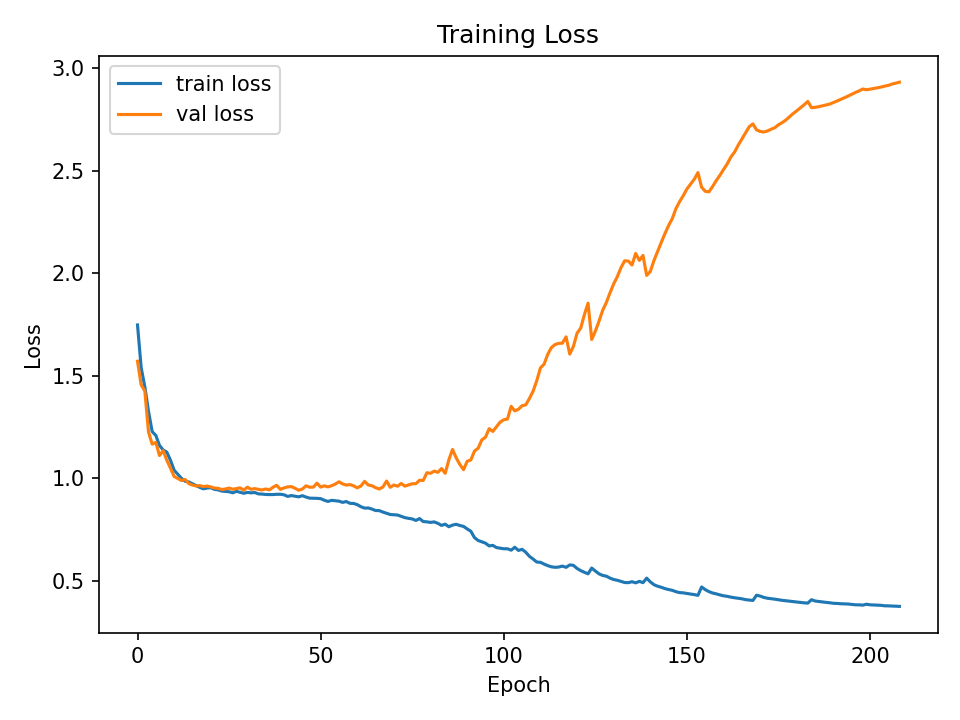


── Accuracy curve ──


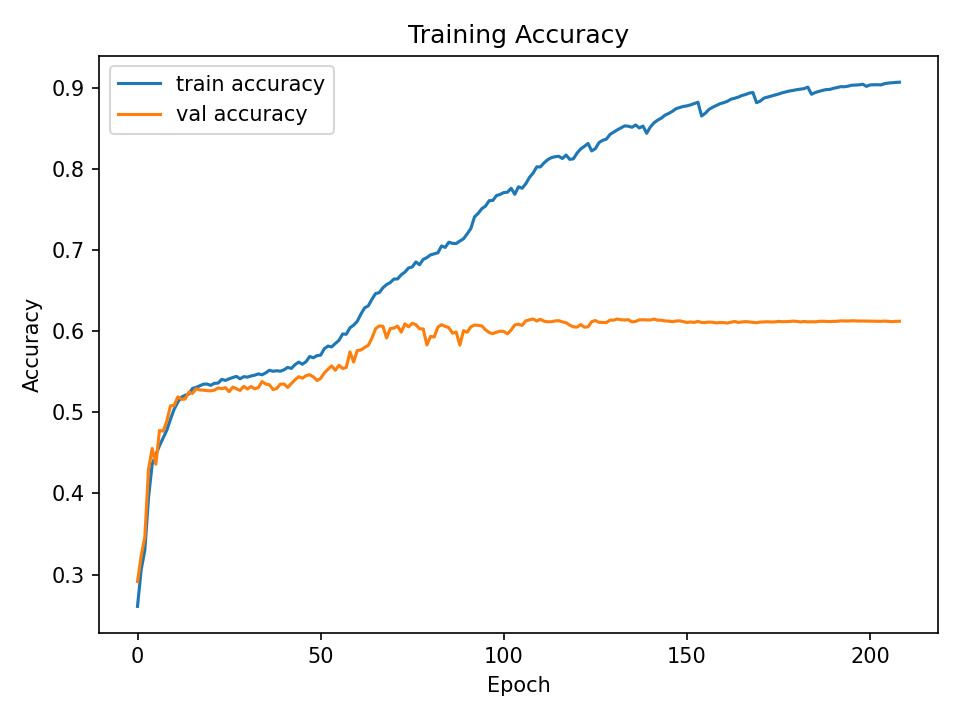


── Overall Accuracy vs SNR ──


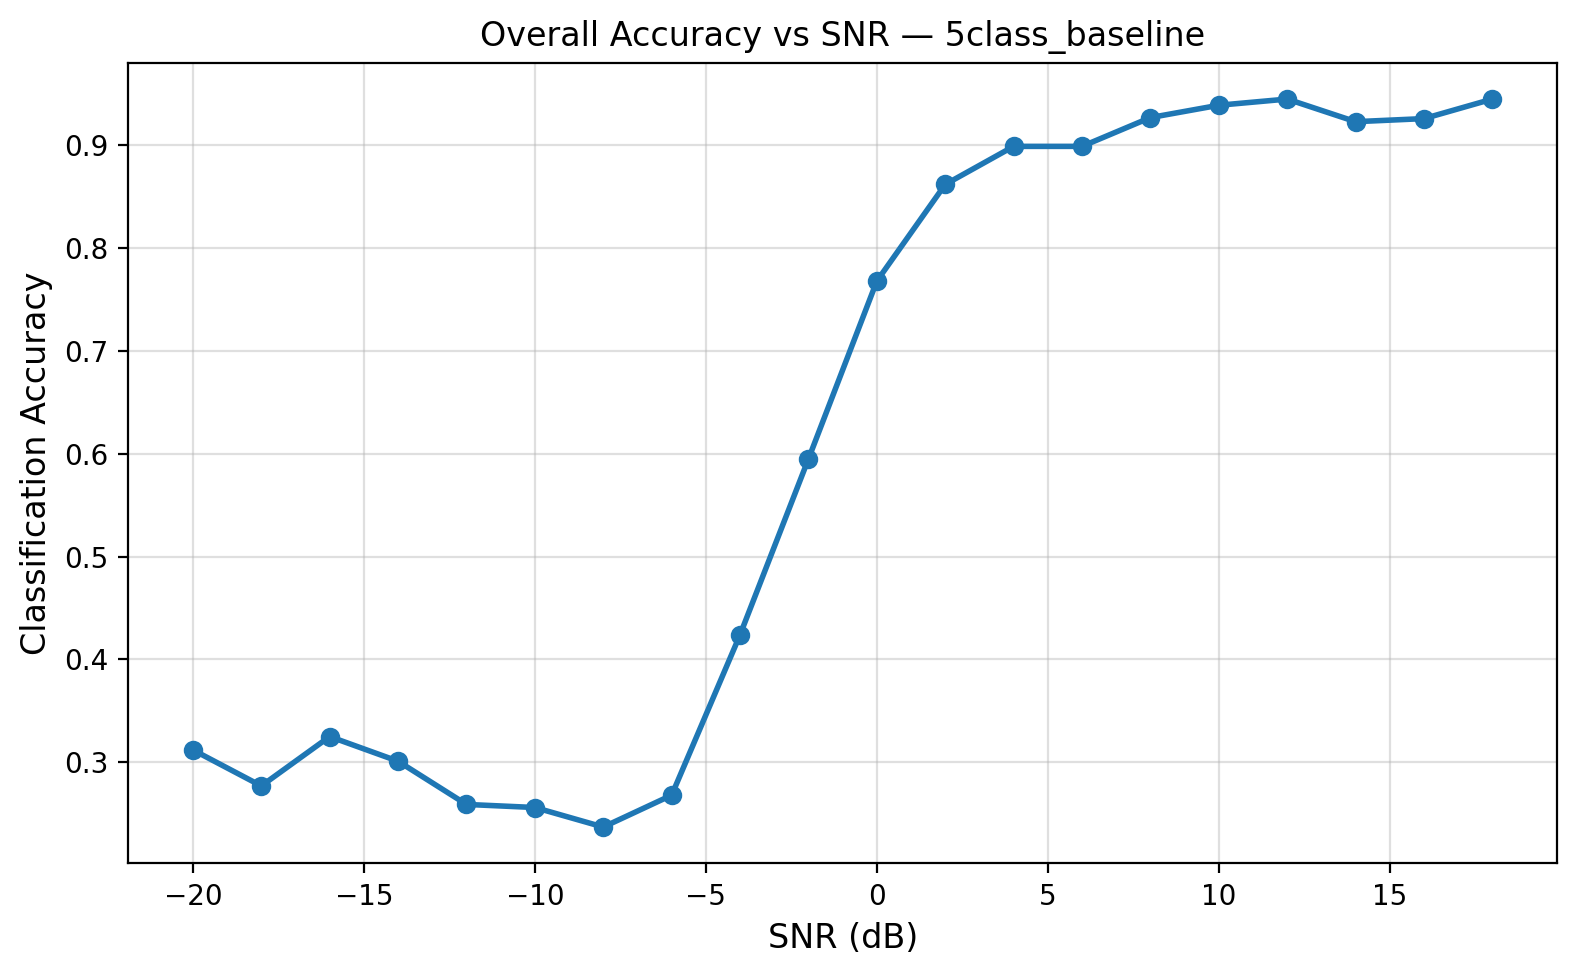


── Per-Class Accuracy vs SNR ──


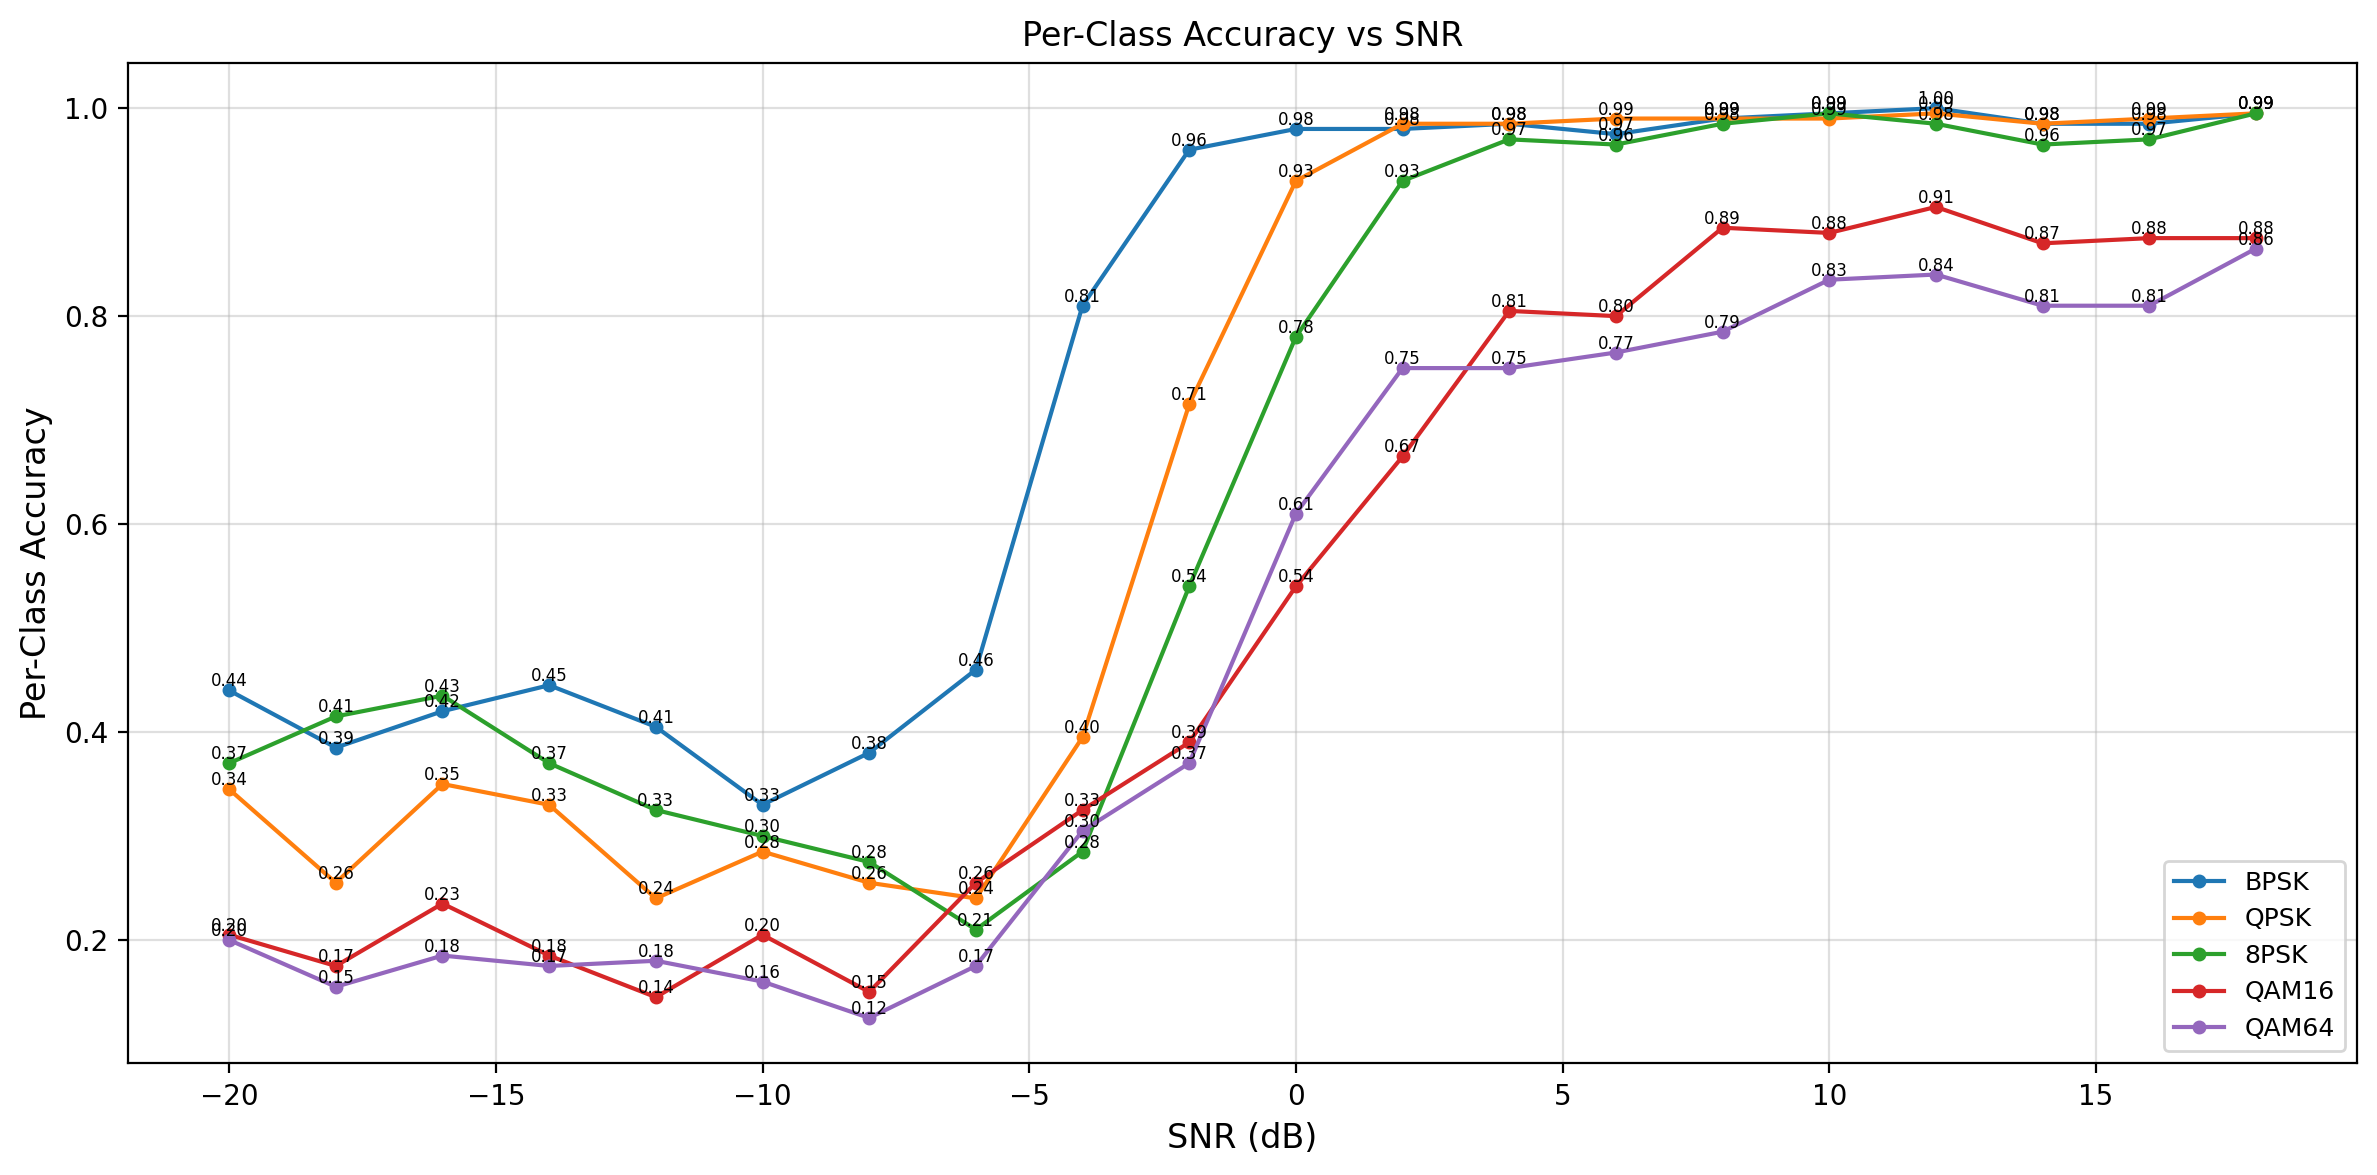


── Confusion Matrix (All SNRs) ──


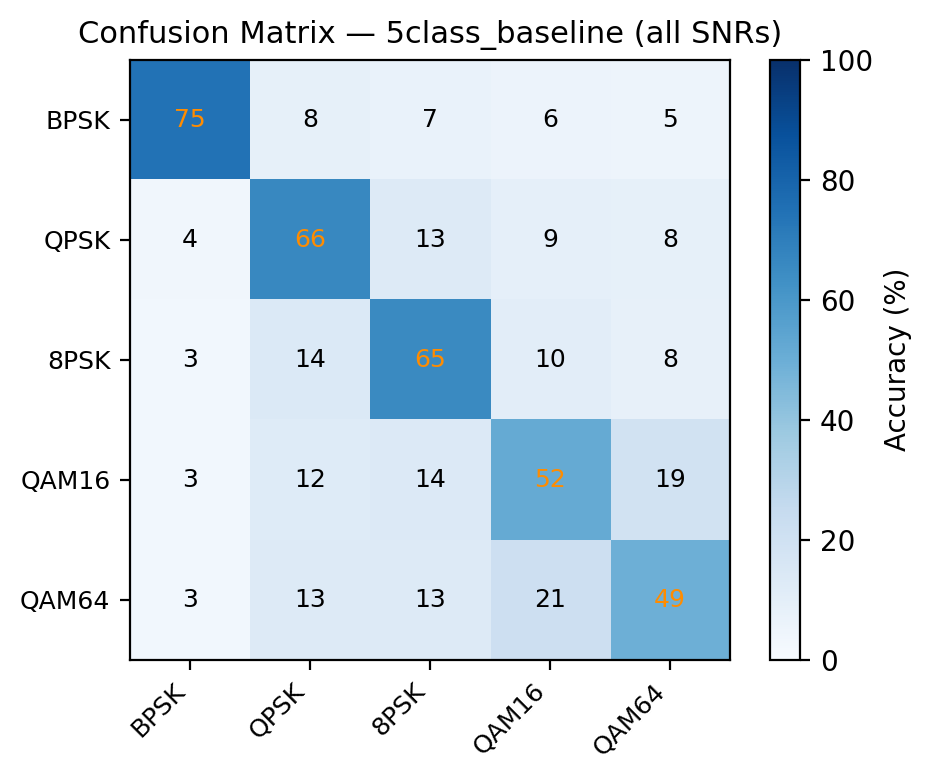


── Per-SNR Confusion Matrices (selected) ──
  SNR = -10 dB


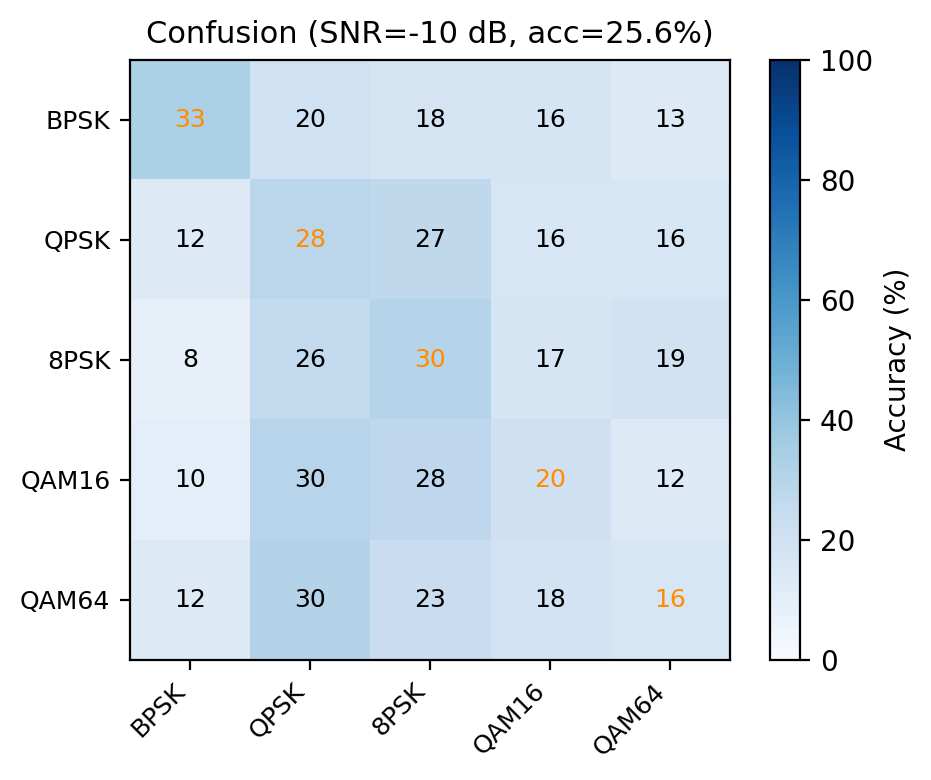

  SNR = -2 dB


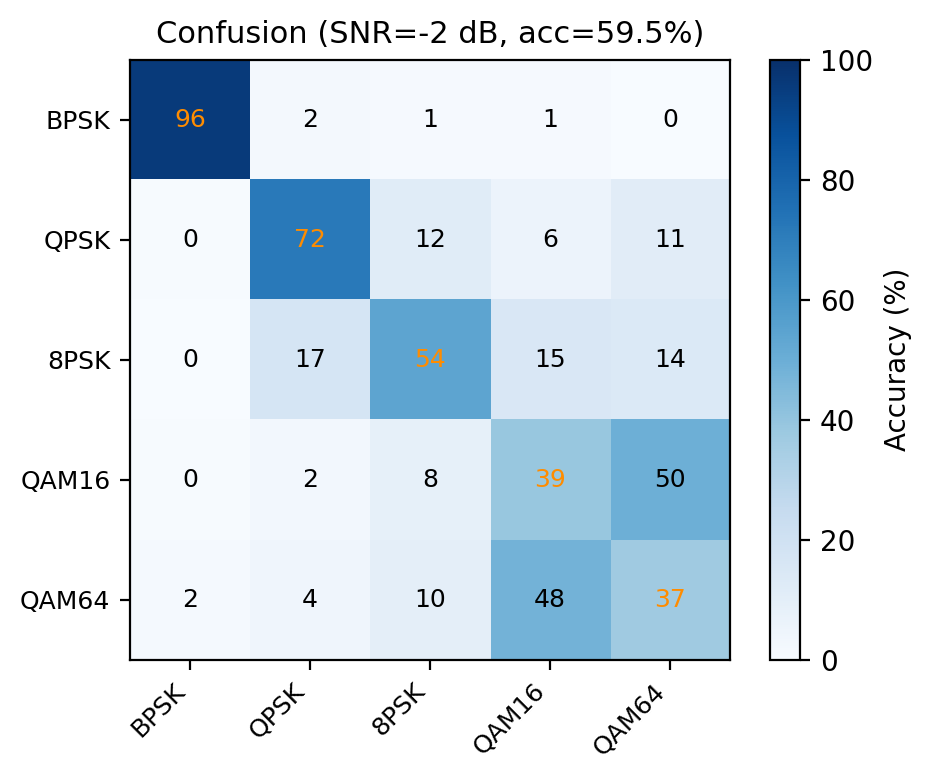

  SNR = +0 dB


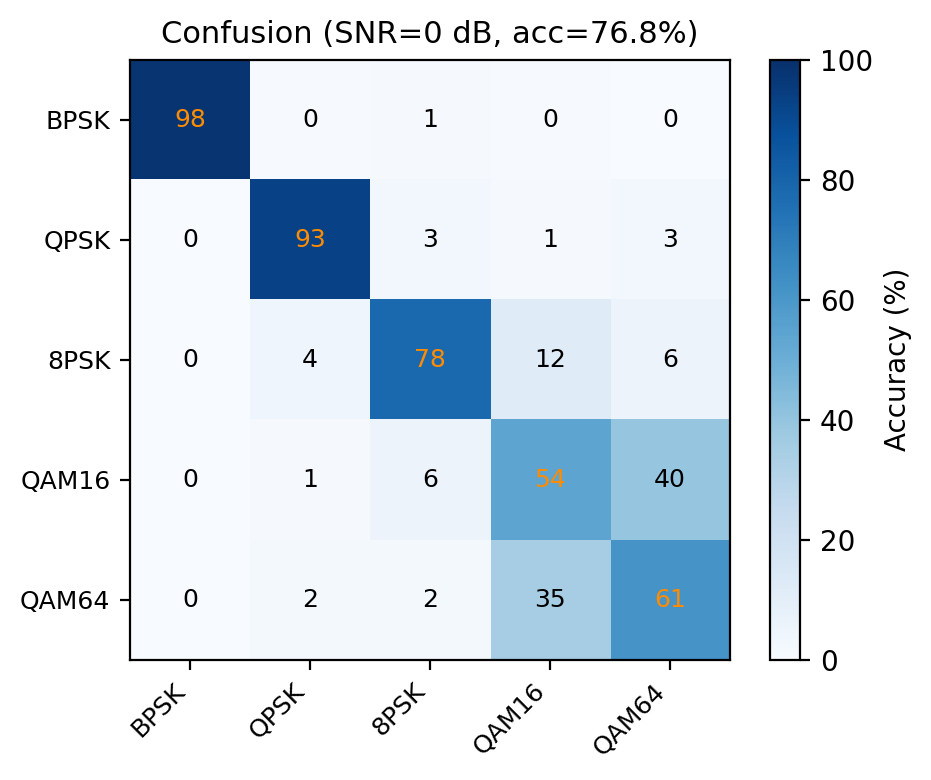

  SNR = +6 dB


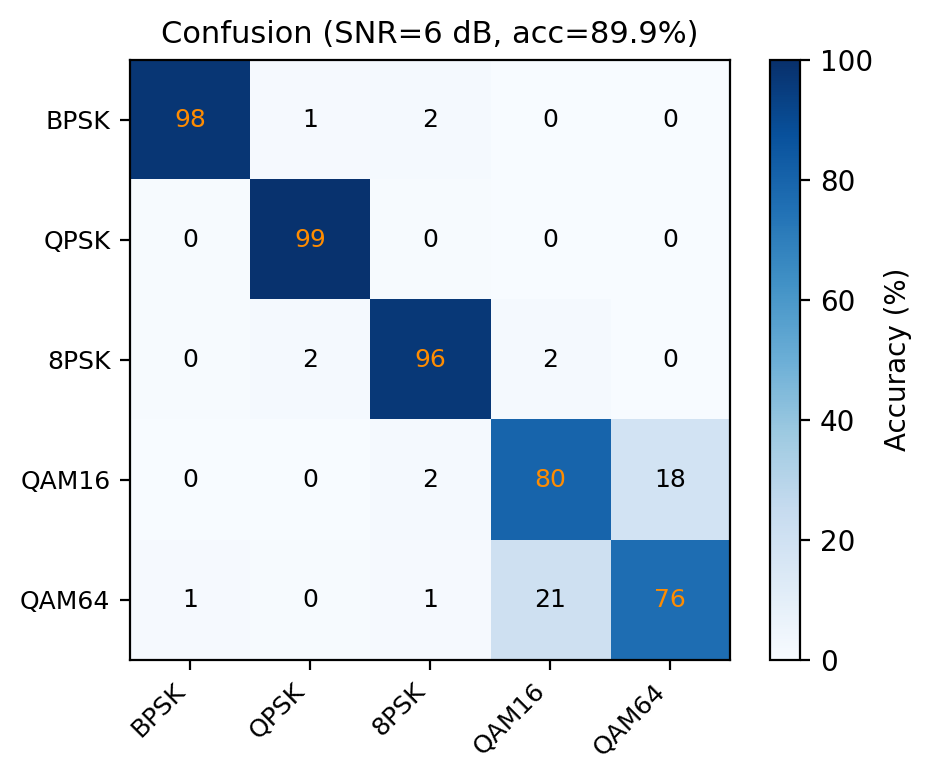

  SNR = +12 dB


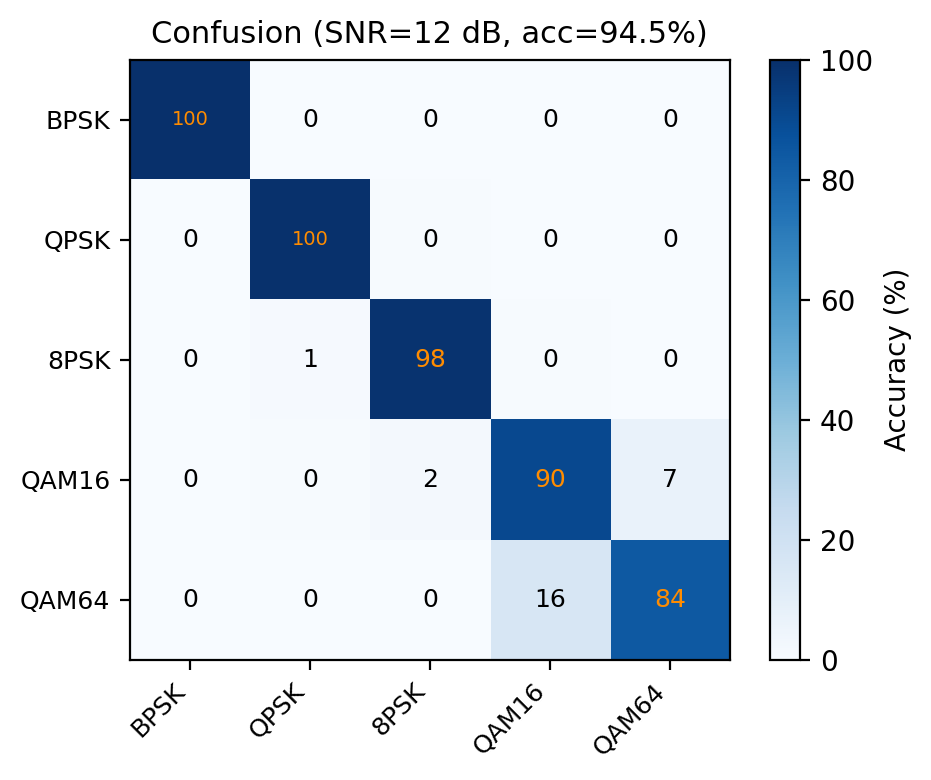

  SNR = +18 dB


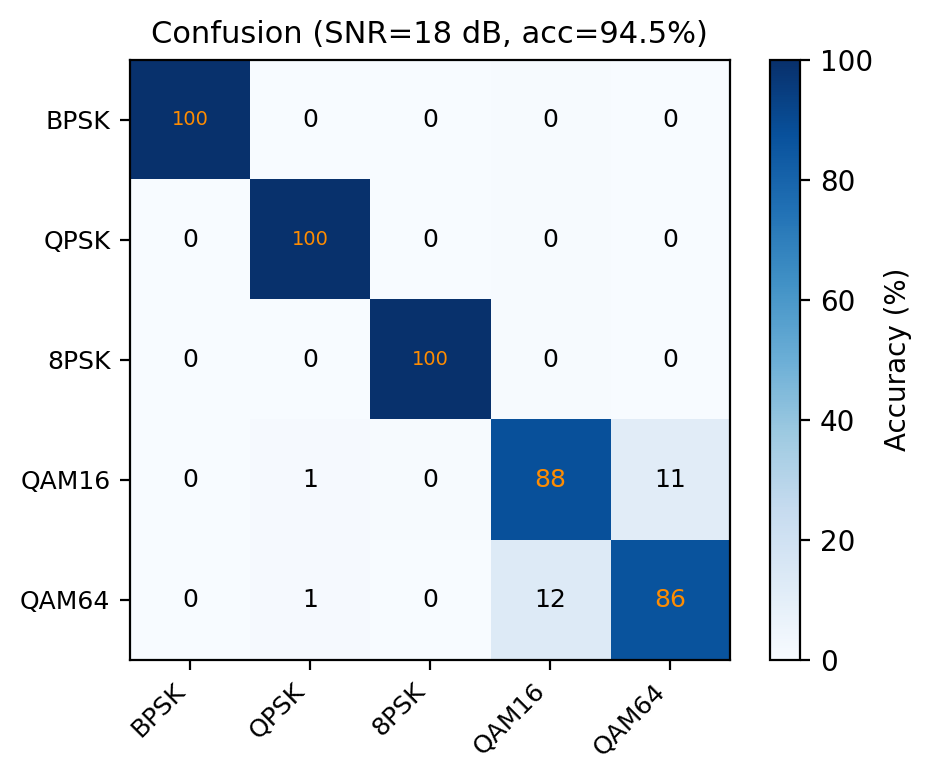

In [22]:
import glob
from IPython.display import Image, display

fig_dir = 'experiments/5class_baseline/figures'
log_dir = 'experiments/5class_baseline/logs'

# Training curves
for name, path in [('Loss curve',     f'{log_dir}/total_loss.png'),
                   ('Accuracy curve', f'{log_dir}/total_acc.png')]:
    if os.path.exists(path):
        print(f"\n── {name} ──")
        display(Image(path))

# Overall accuracy vs SNR
acc_plot = f'{fig_dir}/acc_vs_snr.png'
if os.path.exists(acc_plot):
    print("\n── Overall Accuracy vs SNR ──")
    display(Image(acc_plot))

# Per-class accuracy
cls_plot = f'{fig_dir}/acc_per_class_vs_snr.png'
if os.path.exists(cls_plot):
    print("\n── Per-Class Accuracy vs SNR ──")
    display(Image(cls_plot))

# Total confusion matrix
cm_plot = f'{fig_dir}/confusion_all_snrs.png'
if os.path.exists(cm_plot):
    print("\n── Confusion Matrix (All SNRs) ──")
    display(Image(cm_plot))

# Per-SNR confusion matrices — show a few key ones
print("\n── Per-SNR Confusion Matrices (selected) ──")
for snr in [-10, -2, 0, 6, 12, 18]:
    path = f'{fig_dir}/confusion_snr{snr:+03d}.png'
    if os.path.exists(path):
        print(f"  SNR = {snr:+d} dB")
        display(Image(path))

In [23]:
import shutil, glob

# Collect all experiment outputs
OUT = '/kaggle/working/5class_baseline_results'
os.makedirs(OUT, exist_ok=True)

# Copy full experiments folder
for f in glob.glob('experiments/**/*', recursive=True):
    if os.path.isfile(f):
        dest = os.path.join(OUT, f)
        os.makedirs(os.path.dirname(dest), exist_ok=True)
        shutil.copy2(f, dest)

# Zip it
zip_path = '/kaggle/working/5class_baseline_results'
shutil.make_archive(zip_path, 'zip', OUT)

size = os.path.getsize(zip_path + '.zip') / 1e6
print(f"Saved: {zip_path}.zip  ({size:.2f} MB)")
print(f"\nContents:")
for f in sorted(glob.glob(f'{OUT}/**/*', recursive=True)):
    if os.path.isfile(f):
        print(f"  {f.replace(OUT+'/', '')}  ({os.path.getsize(f)/1e3:.1f} KB)")

Saved: /kaggle/working/5class_baseline_results.zip  (6.38 MB)

Contents:
  experiments/5class_baseline/checkpoints/best_model.weights.h5  (4930.2 KB)
  experiments/5class_baseline/figures/acc_per_class_vs_snr.png  (283.8 KB)
  experiments/5class_baseline/figures/acc_vs_snr.png  (80.5 KB)
  experiments/5class_baseline/figures/confusion_all_snrs.png  (71.9 KB)
  experiments/5class_baseline/figures/confusion_snr+00.png  (68.8 KB)
  experiments/5class_baseline/figures/confusion_snr+02.png  (67.6 KB)
  experiments/5class_baseline/figures/confusion_snr+04.png  (67.5 KB)
  experiments/5class_baseline/figures/confusion_snr+06.png  (67.8 KB)
  experiments/5class_baseline/figures/confusion_snr+08.png  (67.3 KB)
  experiments/5class_baseline/figures/confusion_snr+10.png  (66.0 KB)
  experiments/5class_baseline/figures/confusion_snr+12.png  (66.0 KB)
  experiments/5class_baseline/figures/confusion_snr+14.png  (67.7 KB)
  experiments/5class_baseline/figures/confusion_snr+16.png  (66.2 KB)
  experim

In [26]:
# Install SHAP and rebuild model from saved weights
!pip install shap --quiet

import os, sys, pickle
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import tensorflow as tf
import keras

# ── paths ──────────────────────────────────────────────────────────────────────
WORK_DIR   = '/kaggle/working/AMR-Benchmark'
DATASET    = '/kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat'
WEIGHTS    = f'{WORK_DIR}/experiments/5class_baseline/checkpoints/best_model.weights.h5'
SHAP_DIR   = f'{WORK_DIR}/experiments/5class_baseline/shap'
os.makedirs(SHAP_DIR, exist_ok=True)
os.chdir(WORK_DIR)
if WORK_DIR not in sys.path:
    sys.path.insert(0, WORK_DIR)

assert os.path.exists(WEIGHTS), f"Weights not found: {WEIGHTS}"

# ── rebuild model and load weights ────────────────────────────────────────────
from src.models.mcldnn import MCLDNN
from src.dataset import load_data, FIVE_CLASS

model = MCLDNN(weights=WEIGHTS, classes=5)
model.compile(loss='categorical_crossentropy',
              optimizer=keras.optimizers.Adam(),
              metrics=['accuracy'])
print("Model loaded ✓")
print(f"Total params: {model.count_params():,}")

[MCLDNN] Loaded weights from /kaggle/working/AMR-Benchmark/experiments/5class_baseline/checkpoints/best_model.weights.h5
Model loaded ✓
Total params: 404,401


In [27]:
# Load data and prepare all inputs
(mods, snrs, lbl), \
(X_train, Y_train), \
(X_val, Y_val),     \
(X_test, Y_test),   \
(train_idx, val_idx, test_idx) = load_data(DATASET, FIVE_CLASS, seed=2016)

# ── prepare all three input tensors ───────────────────────────────────────────
def make_inputs(X):
    X_IQ = np.expand_dims(X, axis=3).astype('float32')      # (N, 2, 128, 1)
    X_I  = np.expand_dims(X[:, 0, :], axis=2).astype('float32')  # (N, 128, 1)
    X_Q  = np.expand_dims(X[:, 1, :], axis=2).astype('float32')  # (N, 128, 1)
    return [X_IQ, X_I, X_Q]

inp_train = make_inputs(X_train)
inp_test  = make_inputs(X_test)

# ── get all test predictions ───────────────────────────────────────────────────
print("Running predictions on test set...")
Y_pred_prob = model.predict(inp_test, batch_size=400, verbose=0)
Y_pred      = np.argmax(Y_pred_prob, axis=1)
Y_true      = np.argmax(Y_test, axis=1)
correct_mask = (Y_pred == Y_true)

print(f"Test accuracy: {correct_mask.mean()*100:.2f}%")
print(f"Classes: {mods}")
for i, m in enumerate(mods):
    cls_mask = Y_true == i
    cls_acc  = (Y_pred[cls_mask] == Y_true[cls_mask]).mean()
    print(f"  {m:<8}: {cls_acc*100:.2f}%  ({cls_mask.sum()} samples)")

[dataset] Loading 5 classes: ['BPSK', 'QPSK', '8PSK', 'QAM16', 'QAM64']
[dataset] SNR range: -20 dB to 18 dB  (20 levels)
[dataset] After normalization — train RMS: 1.0000  (should be ≈1.0)
[dataset] Split: 60000 train | 20000 val | 20000 test samples
Running predictions on test set...


I0000 00:00:1780775721.450842   19128 cuda_dnn.cc:529] Loaded cuDNN version 91002


Test accuracy: 61.43%
Classes: ['BPSK', 'QPSK', '8PSK', 'QAM16', 'QAM64']
  BPSK    : 74.52%  (4000 samples)
  QPSK    : 66.22%  (4000 samples)
  8PSK    : 65.33%  (4000 samples)
  QAM16   : 51.85%  (4000 samples)
  QAM64   : 49.25%  (4000 samples)


In [28]:
# Build SHAP explainer (run once, ~3–5 min)
import shap

# ── background: 150 random training samples (mixed classes) ───────────────────
np.random.seed(2016)
bg_idx = np.random.choice(len(X_train), size=150, replace=False)
bg     = [inp_train[0][bg_idx],
          inp_train[1][bg_idx],
          inp_train[2][bg_idx]]

print(f"Background set: {len(bg_idx)} samples")
print(f"  bg[0] (IQ):  {bg[0].shape}")
print(f"  bg[1] (I) :  {bg[1].shape}")
print(f"  bg[2] (Q) :  {bg[2].shape}")

# GradientExplainer works reliably with Keras 3 multi-input models
explainer = shap.GradientExplainer(model, bg)
print("Explainer built ✓")

# ── helper: extract SHAP for a batch of test samples ──────────────────────────
def get_shap(sample_indices):
    """
    Returns I and Q SHAP arrays for the given test sample indices.
    sv_I shape: (N, 128, 1, 5)  → sv_I[:, :, 0, class] = 128 SHAP values per class
    sv_Q shape: (N, 128, 1, 5)
    """
    batch = [inp_test[0][sample_indices],
             inp_test[1][sample_indices],
             inp_test[2][sample_indices]]
    sv = explainer.shap_values(batch)
    # sv is list of 3 arrays: [sv_IQ, sv_I, sv_Q]
    # each shape: (N, *input_shape, n_classes)
    sv_I  = sv[1]   # (N, 128, 1, 5)
    sv_Q  = sv[2]   # (N, 128, 1, 5)
    sv_IQ = sv[0]   # (N, 2, 128, 1, 5)
    return sv_IQ, sv_I, sv_Q

print("get_shap() helper ready ✓")

Background set: 150 samples
  bg[0] (IQ):  (150, 2, 128, 1)
  bg[1] (I) :  (150, 128, 1)
  bg[2] (Q) :  (150, 128, 1)
Explainer built ✓
get_shap() helper ready ✓


In [34]:
# Task 2: SHAP Temporal Distribution Analysis
# ── select correctly classified samples for BPSK, QPSK, 16QAM, 64QAM ─────────
TASK2_CLASSES  = ['BPSK', 'QPSK', 'QAM16', 'QAM64','8PSK']
N_PER_CLASS    = 40   # 40 correct samples per class → 160 total SHAP calls
TIME_STEPS     = np.arange(128)

task2_shap_I = {}   # class_name → (N, 128) mean |SHAP|
task2_shap_Q = {}

print("Task 2: Computing temporal SHAP distributions...")
for cls_name in TASK2_CLASSES:
    cls_idx = mods.index(cls_name)
    # indices in test set that are correct AND belong to this class
    pool = np.where((Y_true == cls_idx) & correct_mask)[0]
    chosen = np.random.choice(pool, size=min(N_PER_CLASS, len(pool)), replace=False)
    pred_cls = Y_pred[chosen]   # all equal to cls_idx for correct samples

    sv_IQ, sv_I, sv_Q = get_shap(chosen)
    # Extract SHAP values for the PREDICTED (= true) class
    # sv_I shape: (N, 128, 1, 5) → take [:, :, 0, cls_idx]
    shap_I_cls = sv_I[:, :, 0, cls_idx]   # (N, 128)
    shap_Q_cls = sv_Q[:, :, 0, cls_idx]   # (N, 128)

    task2_shap_I[cls_name] = shap_I_cls
    task2_shap_Q[cls_name] = shap_Q_cls
    print(f"  {cls_name}: {len(chosen)} samples computed")

# ── Plot: one subplot per class, I and Q overlaid ─────────────────────────────
fig, axes = plt.subplots(len(TASK2_CLASSES), 2, figsize=(16, 4*len(TASK2_CLASSES)))
fig.suptitle('Task 2: SHAP Temporal Distribution — Mean |SHAP| over 128 Time Steps',
             fontsize=14, fontweight='bold', y=1.01)

for row, cls_name in enumerate(TASK2_CLASSES):
    for col, (channel, shap_arr, color) in enumerate([
        ('I channel', task2_shap_I[cls_name], '#1f77b4'),
        ('Q channel', task2_shap_Q[cls_name], '#d62728'),
    ]):
        ax = axes[row, col]
        mean_abs = np.abs(shap_arr).mean(axis=0)   # (128,)
        std_abs  = np.abs(shap_arr).std(axis=0)

        ax.fill_between(TIME_STEPS,
                        mean_abs - std_abs,
                        mean_abs + std_abs,
                        alpha=0.25, color=color)
        ax.plot(TIME_STEPS, mean_abs, color=color, linewidth=1.5,
                label=f'Mean |SHAP|')
        ax.set_title(f'{cls_name} — {channel}', fontsize=11)
        ax.set_xlabel('Time step (0–127)')
        ax.set_ylabel('Mean |SHAP value|')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

        # Annotate peak location
        peak_t = np.argmax(mean_abs)
        ax.axvline(peak_t, color='black', linestyle='--', alpha=0.5, linewidth=1)
        ax.text(peak_t+2, mean_abs.max()*0.9, f't={peak_t}',
                fontsize=8, color='black')

plt.tight_layout()
save_path = f'{SHAP_DIR}/task2_temporal_distribution.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"[Task 2] Saved → {save_path}")

# ── Quantitative: peak-to-mean ratio (sparsity measure) ───────────────────────
print(f"\n{'='*55}")
print(f"  Sparsity: Peak / Mean ratio of |SHAP| over 128 steps")
print(f"  (High ratio = model uses sparse specific time regions)")
print(f"  {'Class':<10} {'I peak/mean':>13} {'Q peak/mean':>13}")
print(f"  {'─'*40}")
for cls_name in TASK2_CLASSES:
    for label, arr in [('I', task2_shap_I[cls_name]),
                       ('Q', task2_shap_Q[cls_name])]:
        mean_abs = np.abs(arr).mean(axis=0)
        ratio = mean_abs.max() / (mean_abs.mean() + 1e-10)
    I_ratio = (np.abs(task2_shap_I[cls_name]).mean(axis=0).max() /
               (np.abs(task2_shap_I[cls_name]).mean(axis=0).mean() + 1e-10))
    Q_ratio = (np.abs(task2_shap_Q[cls_name]).mean(axis=0).max() /
               (np.abs(task2_shap_Q[cls_name]).mean(axis=0).mean() + 1e-10))
    print(f"  {cls_name:<10} {I_ratio:>13.2f} {Q_ratio:>13.2f}")
print(f"{'='*55}")

# Save task2 data
with open(f'{SHAP_DIR}/task2_data.pkl', 'wb') as f:
    pickle.dump({'shap_I': task2_shap_I, 'shap_Q': task2_shap_Q,
                 'mods': mods, 'classes': TASK2_CLASSES}, f)

Task 2: Computing temporal SHAP distributions...
  BPSK: 40 samples computed
  QPSK: 40 samples computed
  QAM16: 40 samples computed
  QAM64: 40 samples computed
  8PSK: 40 samples computed
[Task 2] Saved → /kaggle/working/AMR-Benchmark/experiments/5class_baseline/shap/task2_temporal_distribution.png

  Sparsity: Peak / Mean ratio of |SHAP| over 128 steps
  (High ratio = model uses sparse specific time regions)
  Class        I peak/mean   Q peak/mean
  ────────────────────────────────────────
  BPSK                2.14          1.82
  QPSK                1.70          1.64
  QAM16               1.61          1.60
  QAM64               2.06          1.58
  8PSK                1.84          1.98


In [30]:
# Task 3: I vs Q Quantitative Balance Analysis


# ── Compute SI and SQ for all 5 classes, 60 correct samples each ──────────────
N_PER_CLASS_T3 = 60
ALL_CLASSES = mods   # all 5: BPSK, QPSK, 8PSK, QAM16, QAM64

si_means = {}   # class_name → mean SI across samples
sq_means = {}
si_stds  = {}
sq_stds  = {}
si_all   = {}   # class_name → array of per-sample SI
sq_all   = {}

print("Task 3: Computing SI and SQ for all classes...")
for cls_name in ALL_CLASSES:
    cls_idx = mods.index(cls_name)
    pool    = np.where((Y_true == cls_idx) & correct_mask)[0]
    chosen  = np.random.choice(pool, size=min(N_PER_CLASS_T3, len(pool)), replace=False)

    sv_IQ, sv_I, sv_Q = get_shap(chosen)

    # Per-sample: SI = sum(|SHAP_I(t)|) for t=0..127
    shap_I_cls = sv_I[:, :, 0, cls_idx]   # (N, 128)
    shap_Q_cls = sv_Q[:, :, 0, cls_idx]   # (N, 128)

    SI = np.abs(shap_I_cls).sum(axis=1)   # (N,)
    SQ = np.abs(shap_Q_cls).sum(axis=1)   # (N,)

    si_all[cls_name]   = SI
    sq_all[cls_name]   = SQ
    si_means[cls_name] = SI.mean()
    sq_means[cls_name] = SQ.mean()
    si_stds[cls_name]  = SI.std()
    sq_stds[cls_name]  = SQ.std()
    print(f"  {cls_name:<8}: SI={SI.mean():.4f}±{SI.std():.4f}  "
          f"SQ={SQ.mean():.4f}±{SQ.std():.4f}  "
          f"I/(I+Q)={SI.mean()/(SI.mean()+SQ.mean())*100:.1f}%")

# ── Grouped bar chart ──────────────────────────────────────────────────────────
x      = np.arange(len(ALL_CLASSES))
width  = 0.35
fig, ax = plt.subplots(figsize=(11, 6))

bars_I = ax.bar(x - width/2,
                [si_means[c] for c in ALL_CLASSES],
                width, yerr=[si_stds[c] for c in ALL_CLASSES],
                label='SI (I channel)', color='#1f77b4', alpha=0.85,
                capsize=5, error_kw={'linewidth':1.5})
bars_Q = ax.bar(x + width/2,
                [sq_means[c] for c in ALL_CLASSES],
                width, yerr=[sq_stds[c] for c in ALL_CLASSES],
                label='SQ (Q channel)', color='#d62728', alpha=0.85,
                capsize=5, error_kw={'linewidth':1.5})

# Annotate I/(I+Q) ratio on top of each pair
for i, cls_name in enumerate(ALL_CLASSES):
    si = si_means[cls_name]; sq = sq_means[cls_name]
    ratio = si / (si + sq) * 100
    ax.text(i, max(si, sq) + max(si_stds[cls_name], sq_stds[cls_name]) + 0.001,
            f'{ratio:.1f}% I',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Modulation Class', fontsize=12)
ax.set_ylabel('Total |SHAP| importance (SI or SQ)', fontsize=12)
ax.set_title('Task 3: I vs Q Channel Importance per Modulation Class\n'
             'Error bars = ±1 std across correctly classified samples',
             fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(ALL_CLASSES, fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

save_path = f'{SHAP_DIR}/task3_IQ_balance.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"[Task 3] Saved → {save_path}")

# ── Print table ───────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  {'Class':<10} {'SI':>10} {'SQ':>10} {'I%':>8} {'Bias':>12}")
print(f"  {'─'*50}")
for cls_name in ALL_CLASSES:
    si = si_means[cls_name]; sq = sq_means[cls_name]
    ratio = si / (si + sq) * 100
    bias  = 'I-dominant' if ratio > 55 else ('Q-dominant' if ratio < 45 else 'Balanced')
    print(f"  {cls_name:<10} {si:>10.4f} {sq:>10.4f} {ratio:>7.1f}% {bias:>12}")
print(f"{'='*60}")

with open(f'{SHAP_DIR}/task3_data.pkl', 'wb') as f:
    pickle.dump({'si_all': si_all, 'sq_all': sq_all,
                 'si_means': si_means, 'sq_means': sq_means,
                 'si_stds': si_stds, 'sq_stds': sq_stds,
                 'classes': ALL_CLASSES}, f)

Task 3: Computing SI and SQ for all classes...
  BPSK    : SI=0.8728±0.4128  SQ=0.9572±0.4955  I/(I+Q)=47.7%
  QPSK    : SI=1.4241±0.4938  SQ=1.4187±0.5013  I/(I+Q)=50.1%
  8PSK    : SI=1.6974±0.5349  SQ=1.6865±0.5753  I/(I+Q)=50.2%
  QAM16   : SI=1.8472±0.6004  SQ=1.9006±0.6359  I/(I+Q)=49.3%
  QAM64   : SI=1.8364±0.6809  SQ=1.8130±0.7181  I/(I+Q)=50.3%
[Task 3] Saved → /kaggle/working/AMR-Benchmark/experiments/5class_baseline/shap/task3_IQ_balance.png

  Class              SI         SQ       I%         Bias
  ──────────────────────────────────────────────────
  BPSK           0.8728     0.9572    47.7%     Balanced
  QPSK           1.4241     1.4187    50.1%     Balanced
  8PSK           1.6974     1.6865    50.2%     Balanced
  QAM16          1.8472     1.9006    49.3%     Balanced
  QAM64          1.8364     1.8130    50.3%     Balanced


In [31]:
# Task 4: SNR-Wise Focus Dispersion Analysis



# ── SNR buckets as specified in task ──────────────────────────────────────────
SNR_BUCKETS = [-10, -4, 0, 10]
N_PER_SNR   = 30   # samples per bucket (across all classes)
test_SNRs   = np.array([lbl[test_idx[j]][1] for j in range(len(test_idx))])

dispersion_I = {snr: [] for snr in SNR_BUCKETS}  # list of variance values
dispersion_Q = {snr: [] for snr in SNR_BUCKETS}
mean_abs_I   = {snr: None for snr in SNR_BUCKETS}
mean_abs_Q   = {snr: None for snr in SNR_BUCKETS}

print("Task 4: Computing SNR-wise SHAP dispersion...")
for snr in SNR_BUCKETS:
    # Correct samples at this SNR (any class)
    snr_and_correct = np.where((test_SNRs == snr) & correct_mask)[0]
    chosen = np.random.choice(snr_and_correct,
                              size=min(N_PER_SNR, len(snr_and_correct)),
                              replace=False)
    pred_classes = Y_pred[chosen]

    sv_IQ, sv_I, sv_Q = get_shap(chosen)

    # Extract SHAP for each sample's own predicted class
    shap_I_arr = np.array([sv_I[i, :, 0, pred_classes[i]]
                            for i in range(len(chosen))])   # (N, 128)
    shap_Q_arr = np.array([sv_Q[i, :, 0, pred_classes[i]]
                            for i in range(len(chosen))])

    # Variance over 128 time steps per sample, then mean across samples
    var_I = np.abs(shap_I_arr).var(axis=1)   # (N,) variance over time
    var_Q = np.abs(shap_Q_arr).var(axis=1)

    dispersion_I[snr] = var_I
    dispersion_Q[snr] = var_Q
    mean_abs_I[snr]   = np.abs(shap_I_arr).mean(axis=0)  # (128,) mean profile
    mean_abs_Q[snr]   = np.abs(shap_Q_arr).mean(axis=0)

    par_I = np.abs(shap_I_arr).mean(axis=0).max() / \
            (np.abs(shap_I_arr).mean(axis=0).mean() + 1e-10)
    par_Q = np.abs(shap_Q_arr).mean(axis=0).max() / \
            (np.abs(shap_Q_arr).mean(axis=0).mean() + 1e-10)
    print(f"  SNR={snr:>4} dB: {len(chosen)} samples | "
          f"Var_I={var_I.mean():.5f}  Var_Q={var_Q.mean():.5f} | "
          f"PAR_I={par_I:.2f}  PAR_Q={par_Q:.2f}")

# ── Plot 1: SHAP temporal profiles at each SNR ────────────────────────────────
fig, axes = plt.subplots(2, len(SNR_BUCKETS), figsize=(16, 7), sharey='row')
fig.suptitle('Task 4: SHAP Temporal Profile at Different SNR Levels\n'
             '(Flat = model distracted by noise; Peaked = focused)',
             fontsize=13, fontweight='bold')

colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']  # red→orange→green→blue
for col, (snr, color) in enumerate(zip(SNR_BUCKETS, colors)):
    for row, (channel, arr) in enumerate([('I channel', mean_abs_I[snr]),
                                           ('Q channel', mean_abs_Q[snr])]):
        ax = axes[row, col]
        ax.fill_between(TIME_STEPS, 0, arr, alpha=0.35, color=color)
        ax.plot(TIME_STEPS, arr, color=color, linewidth=1.5)
        ax.set_title(f'SNR = {snr:+d} dB', fontsize=11, color=color,
                     fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'{channel}\nMean |SHAP|', fontsize=10)
        ax.set_xlabel('Time step')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
save_path = f'{SHAP_DIR}/task4_snr_temporal_profiles.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"[Task 4] Saved → {save_path}")

# ── Plot 2: Dispersion (variance) vs SNR bar chart ────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
snr_labels = [f'{s:+d} dB' for s in SNR_BUCKETS]
x = np.arange(len(SNR_BUCKETS))
w = 0.35

ax.bar(x - w/2, [dispersion_I[s].mean() for s in SNR_BUCKETS], w,
       yerr=[dispersion_I[s].std() for s in SNR_BUCKETS],
       label='I channel variance', color='#1f77b4', alpha=0.85, capsize=5)
ax.bar(x + w/2, [dispersion_Q[s].mean() for s in SNR_BUCKETS], w,
       yerr=[dispersion_Q[s].std() for s in SNR_BUCKETS],
       label='Q channel variance', color='#d62728', alpha=0.85, capsize=5)

ax.set_xlabel('SNR level', fontsize=12)
ax.set_ylabel('SHAP temporal variance\n(higher = more scattered focus)', fontsize=11)
ax.set_title('Task 4: Focus Dispersion vs SNR\n'
             'Higher variance = model attention scattered across time steps',
             fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(snr_labels, fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

save_path2 = f'{SHAP_DIR}/task4_dispersion_vs_snr.png'
fig.savefig(save_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f"[Task 4] Saved → {save_path2}")

with open(f'{SHAP_DIR}/task4_data.pkl', 'wb') as f:
    pickle.dump({'dispersion_I': dispersion_I, 'dispersion_Q': dispersion_Q,
                 'mean_abs_I': mean_abs_I, 'mean_abs_Q': mean_abs_Q,
                 'snrs': SNR_BUCKETS}, f)

Task 4: Computing SNR-wise SHAP dispersion...
  SNR= -10 dB: 30 samples | Var_I=0.00014  Var_Q=0.00014 | PAR_I=2.15  PAR_Q=2.11
  SNR=  -4 dB: 30 samples | Var_I=0.00024  Var_Q=0.00026 | PAR_I=1.83  PAR_Q=1.83
  SNR=   0 dB: 30 samples | Var_I=0.00018  Var_Q=0.00019 | PAR_I=1.65  PAR_Q=1.96
  SNR=  10 dB: 30 samples | Var_I=0.00017  Var_Q=0.00020 | PAR_I=1.75  PAR_Q=1.68
[Task 4] Saved → /kaggle/working/AMR-Benchmark/experiments/5class_baseline/shap/task4_snr_temporal_profiles.png
[Task 4] Saved → /kaggle/working/AMR-Benchmark/experiments/5class_baseline/shap/task4_dispersion_vs_snr.png


In [32]:
# Task 5: 16-QAM vs 64-QAM Confusion Analysis


# ── Build the four analysis pools ─────────────────────────────────────────────
idx_16 = mods.index('QAM16')
idx_64 = mods.index('QAM64')

pools = {
    'A_16QAM_correct'      : np.where((Y_true == idx_16) & (Y_pred == idx_16))[0],
    'B_16QAM_as_64QAM'     : np.where((Y_true == idx_16) & (Y_pred == idx_64))[0],
    'C_64QAM_correct'      : np.where((Y_true == idx_64) & (Y_pred == idx_64))[0],
    'D_64QAM_as_16QAM'     : np.where((Y_true == idx_64) & (Y_pred == idx_16))[0],
}

N_TASK5 = 30
print("Task 5: Pool sizes:")
for name, pool in pools.items():
    print(f"  {name}: {len(pool)} samples")
    if len(pool) < 5:
        print(f"    ⚠️  Very few samples — results may be noisy")

# ── Compute SHAP for each pool ────────────────────────────────────────────────
pool_shap_I = {}   # pool_name → mean |SHAP_I| over 128 steps
pool_shap_Q = {}
pool_SI     = {}   # pool_name → mean total SI
pool_SQ     = {}

# For each pool, which class do we extract SHAP for?
# For correct pools: extract for the true class
# For misclassified: extract for the PREDICTED (wrong) class to see what the model "sees"
pool_class = {
    'A_16QAM_correct'  : idx_16,
    'B_16QAM_as_64QAM' : idx_64,   # model predicted 64QAM
    'C_64QAM_correct'  : idx_64,
    'D_64QAM_as_16QAM' : idx_16,   # model predicted 16QAM
}

print("\nComputing SHAP for all 4 pools...")
for pool_name, pool_indices in pools.items():
    if len(pool_indices) == 0:
        print(f"  {pool_name}: SKIPPED (empty)")
        pool_shap_I[pool_name] = None
        pool_shap_Q[pool_name] = None
        continue

    chosen  = np.random.choice(pool_indices,
                                size=min(N_TASK5, len(pool_indices)),
                                replace=False)
    cls_idx = pool_class[pool_name]

    sv_IQ, sv_I, sv_Q = get_shap(chosen)
    shap_I = sv_I[:, :, 0, cls_idx]   # (N, 128)
    shap_Q = sv_Q[:, :, 0, cls_idx]   # (N, 128)

    pool_shap_I[pool_name] = np.abs(shap_I).mean(axis=0)   # (128,)
    pool_shap_Q[pool_name] = np.abs(shap_Q).mean(axis=0)
    pool_SI[pool_name]     = np.abs(shap_I).sum(axis=1).mean()
    pool_SQ[pool_name]     = np.abs(shap_Q).sum(axis=1).mean()

    print(f"  {pool_name}: {len(chosen)} samples | "
          f"SI={pool_SI[pool_name]:.4f}  SQ={pool_SQ[pool_name]:.4f}")

# ── Plot: 2x2 grid, I channel left, Q channel right ───────────────────────────
pool_labels = {
    'A_16QAM_correct'  : 'A: 16-QAM → 16-QAM ✓',
    'B_16QAM_as_64QAM' : 'B: 16-QAM → 64-QAM ✗',
    'C_64QAM_correct'  : 'C: 64-QAM → 64-QAM ✓',
    'D_64QAM_as_16QAM' : 'D: 64-QAM → 16-QAM ✗',
}
colors_pool = {
    'A_16QAM_correct'  : '#2ca02c',
    'B_16QAM_as_64QAM' : '#d62728',
    'C_64QAM_correct'  : '#1f77b4',
    'D_64QAM_as_16QAM' : '#ff7f0e',
}

fig, axes = plt.subplots(4, 2, figsize=(16, 14))
fig.suptitle('Task 5: 16-QAM vs 64-QAM Confusion — SHAP Feature Importance\n'
             'Left: I channel   Right: Q channel',
             fontsize=13, fontweight='bold')

for row, pool_name in enumerate(pools.keys()):
    for col, (channel, shap_arr) in enumerate([
        ('I channel', pool_shap_I[pool_name]),
        ('Q channel', pool_shap_Q[pool_name]),
    ]):
        ax = axes[row, col]
        if shap_arr is None:
            ax.text(0.5, 0.5, 'Insufficient samples',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{pool_labels[pool_name]} — {channel}')
            continue
        color = colors_pool[pool_name]
        ax.fill_between(TIME_STEPS, 0, shap_arr, alpha=0.3, color=color)
        ax.plot(TIME_STEPS, shap_arr, color=color, linewidth=1.5)
        ax.set_title(f'{pool_labels[pool_name]}\n{channel}', fontsize=10)
        ax.set_xlabel('Time step (0–127)')
        ax.set_ylabel('Mean |SHAP|')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
save_path = f'{SHAP_DIR}/task5_confusion_analysis.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"[Task 5] Saved → {save_path}")

# ── Plot 2: SI/SQ comparison for correct vs confused ─────────────────────────
valid_pools = [p for p in pools if pool_shap_I[p] is not None]
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(valid_pools))
w = 0.35
ax.bar(x - w/2, [pool_SI[p] for p in valid_pools], w,
       label='SI (I channel)', color=[colors_pool[p] for p in valid_pools],
       alpha=0.85)
ax.bar(x + w/2, [pool_SQ[p] for p in valid_pools], w,
       label='SQ (Q channel)', color=[colors_pool[p] for p in valid_pools],
       alpha=0.5, hatch='//')
ax.set_xticks(x)
ax.set_xticklabels([pool_labels[p] for p in valid_pools], fontsize=9)
ax.set_ylabel('Total |SHAP| importance', fontsize=11)
ax.set_title('Task 5: Channel Importance — Correct vs Confused Predictions', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
save_path2 = f'{SHAP_DIR}/task5_SI_SQ_comparison.png'
fig.savefig(save_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f"[Task 5] Saved → {save_path2}")

with open(f'{SHAP_DIR}/task5_data.pkl', 'wb') as f:
    pickle.dump({'pool_shap_I': pool_shap_I, 'pool_shap_Q': pool_shap_Q,
                 'pool_SI': pool_SI, 'pool_SQ': pool_SQ,
                 'pool_labels': pool_labels}, f)

Task 5: Pool sizes:
  A_16QAM_correct: 2074 samples
  B_16QAM_as_64QAM: 777 samples
  C_64QAM_correct: 1970 samples
  D_64QAM_as_16QAM: 856 samples

Computing SHAP for all 4 pools...
  A_16QAM_correct: 30 samples | SI=1.7265  SQ=1.7446
  B_16QAM_as_64QAM: 30 samples | SI=1.6537  SQ=1.7100
  C_64QAM_correct: 30 samples | SI=1.8162  SQ=1.8160
  D_64QAM_as_16QAM: 30 samples | SI=1.6572  SQ=1.7723
[Task 5] Saved → /kaggle/working/AMR-Benchmark/experiments/5class_baseline/shap/task5_confusion_analysis.png
[Task 5] Saved → /kaggle/working/AMR-Benchmark/experiments/5class_baseline/shap/task5_SI_SQ_comparison.png



── Task 2 — Temporal Distribution ──


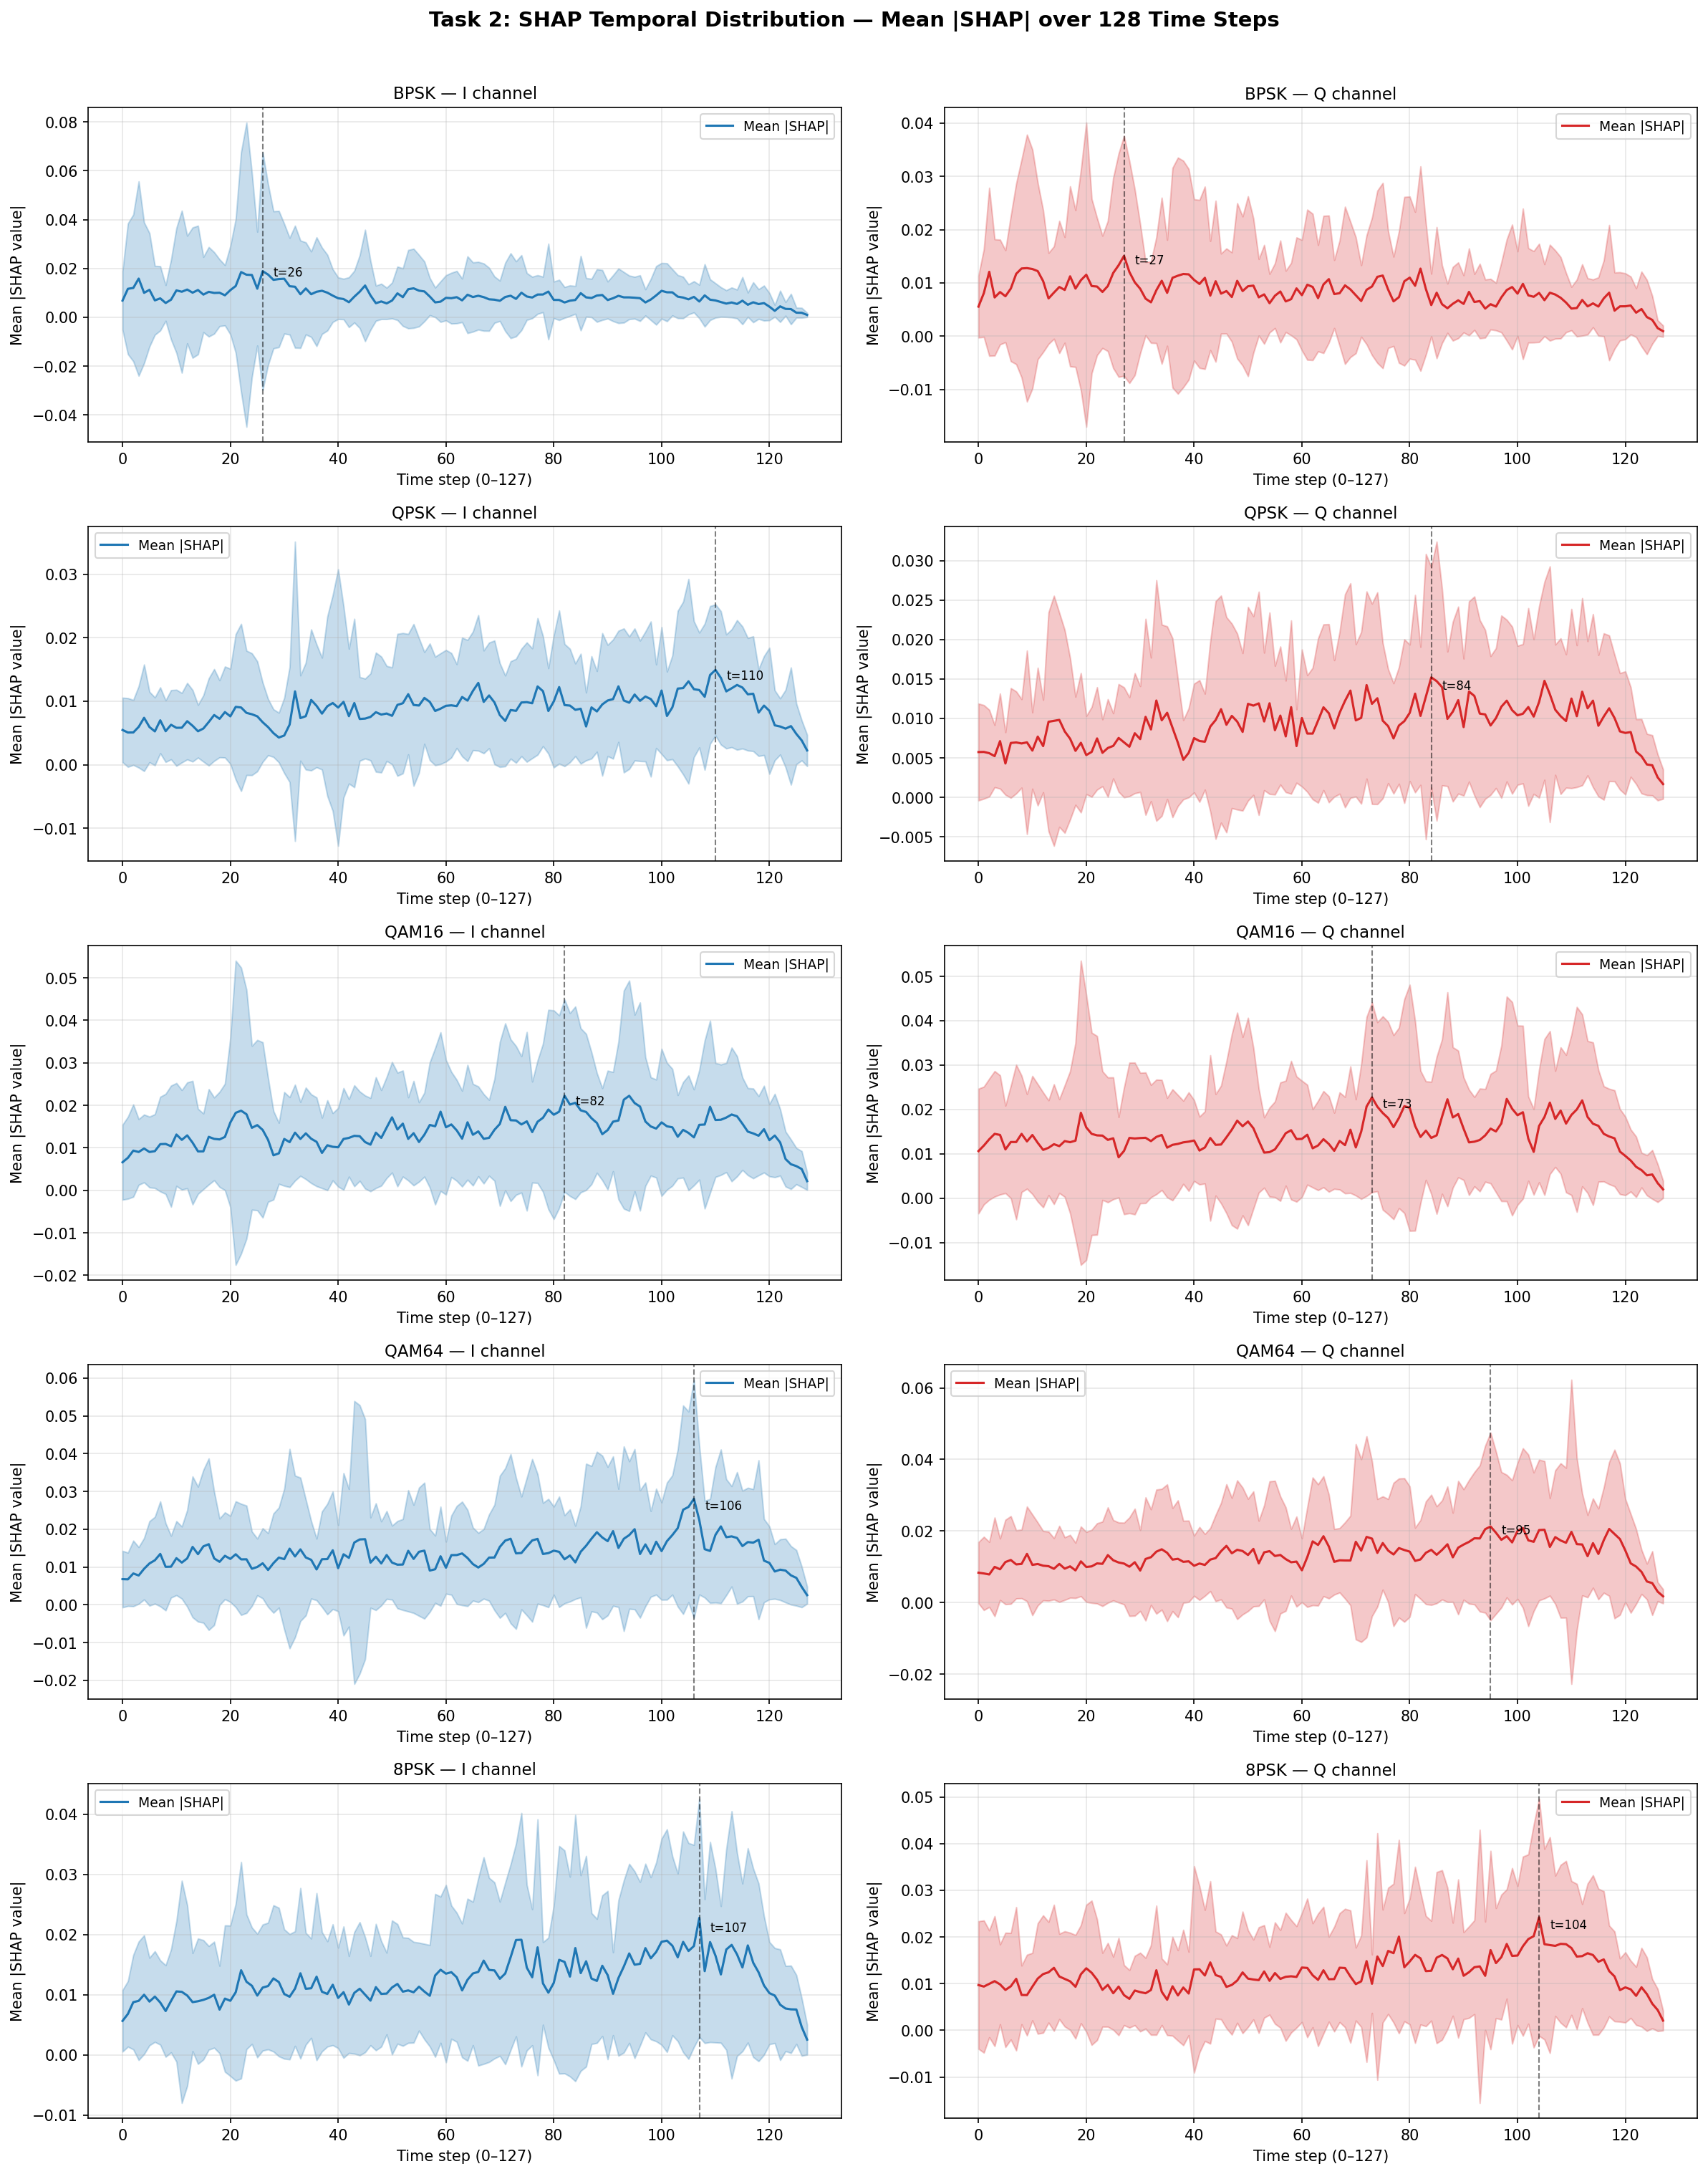


── Task 3 — I vs Q Balance ──


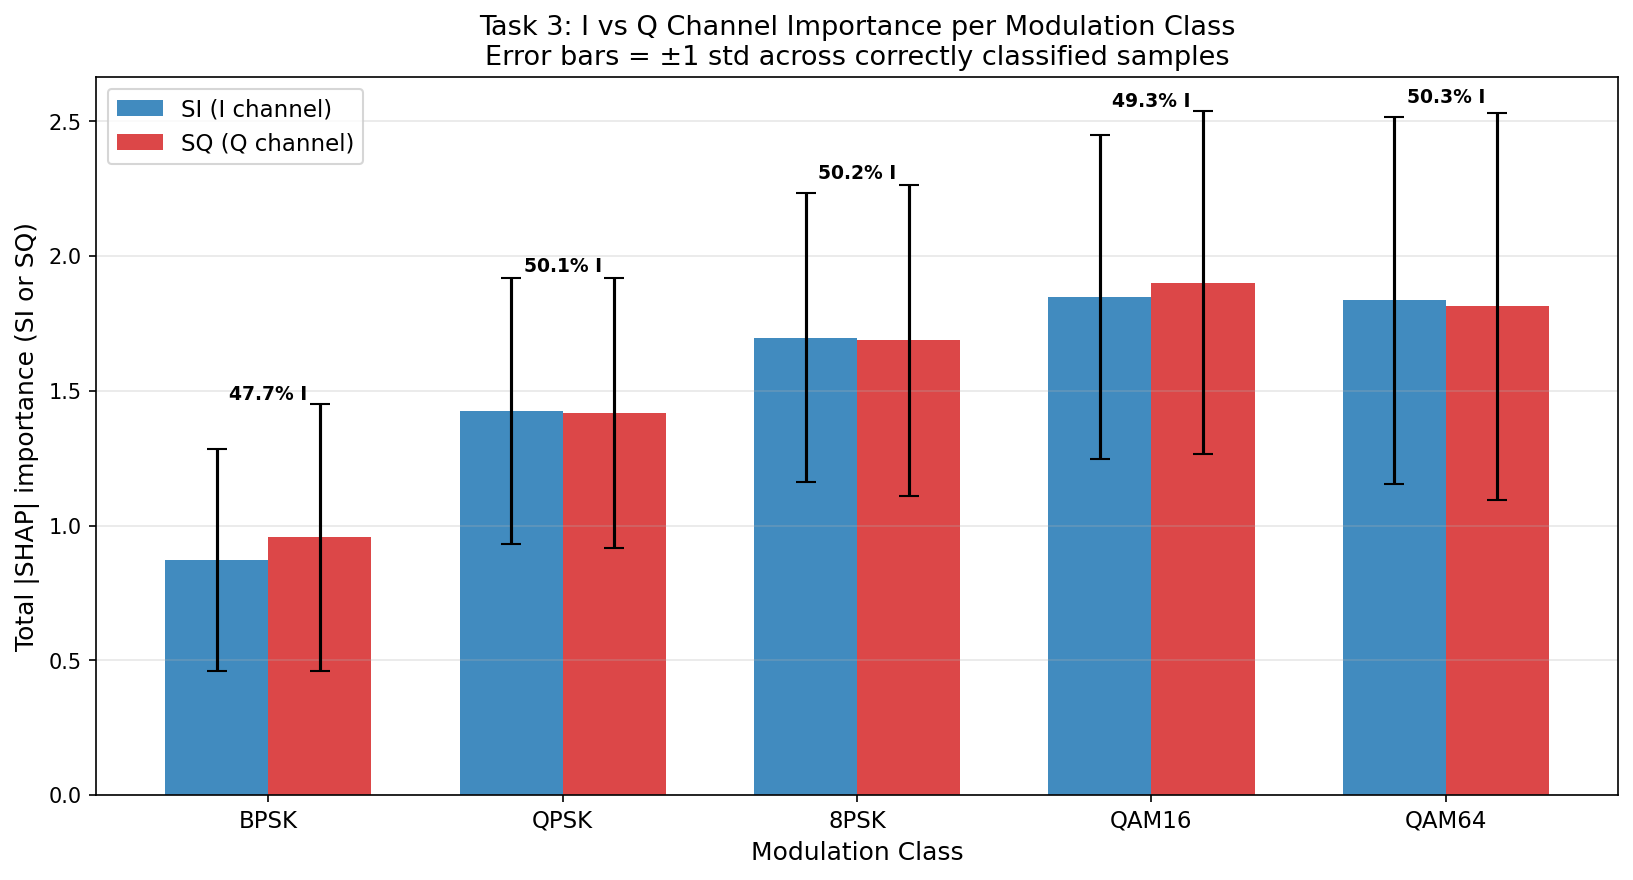


── Task 4 — SNR Temporal Profiles ──


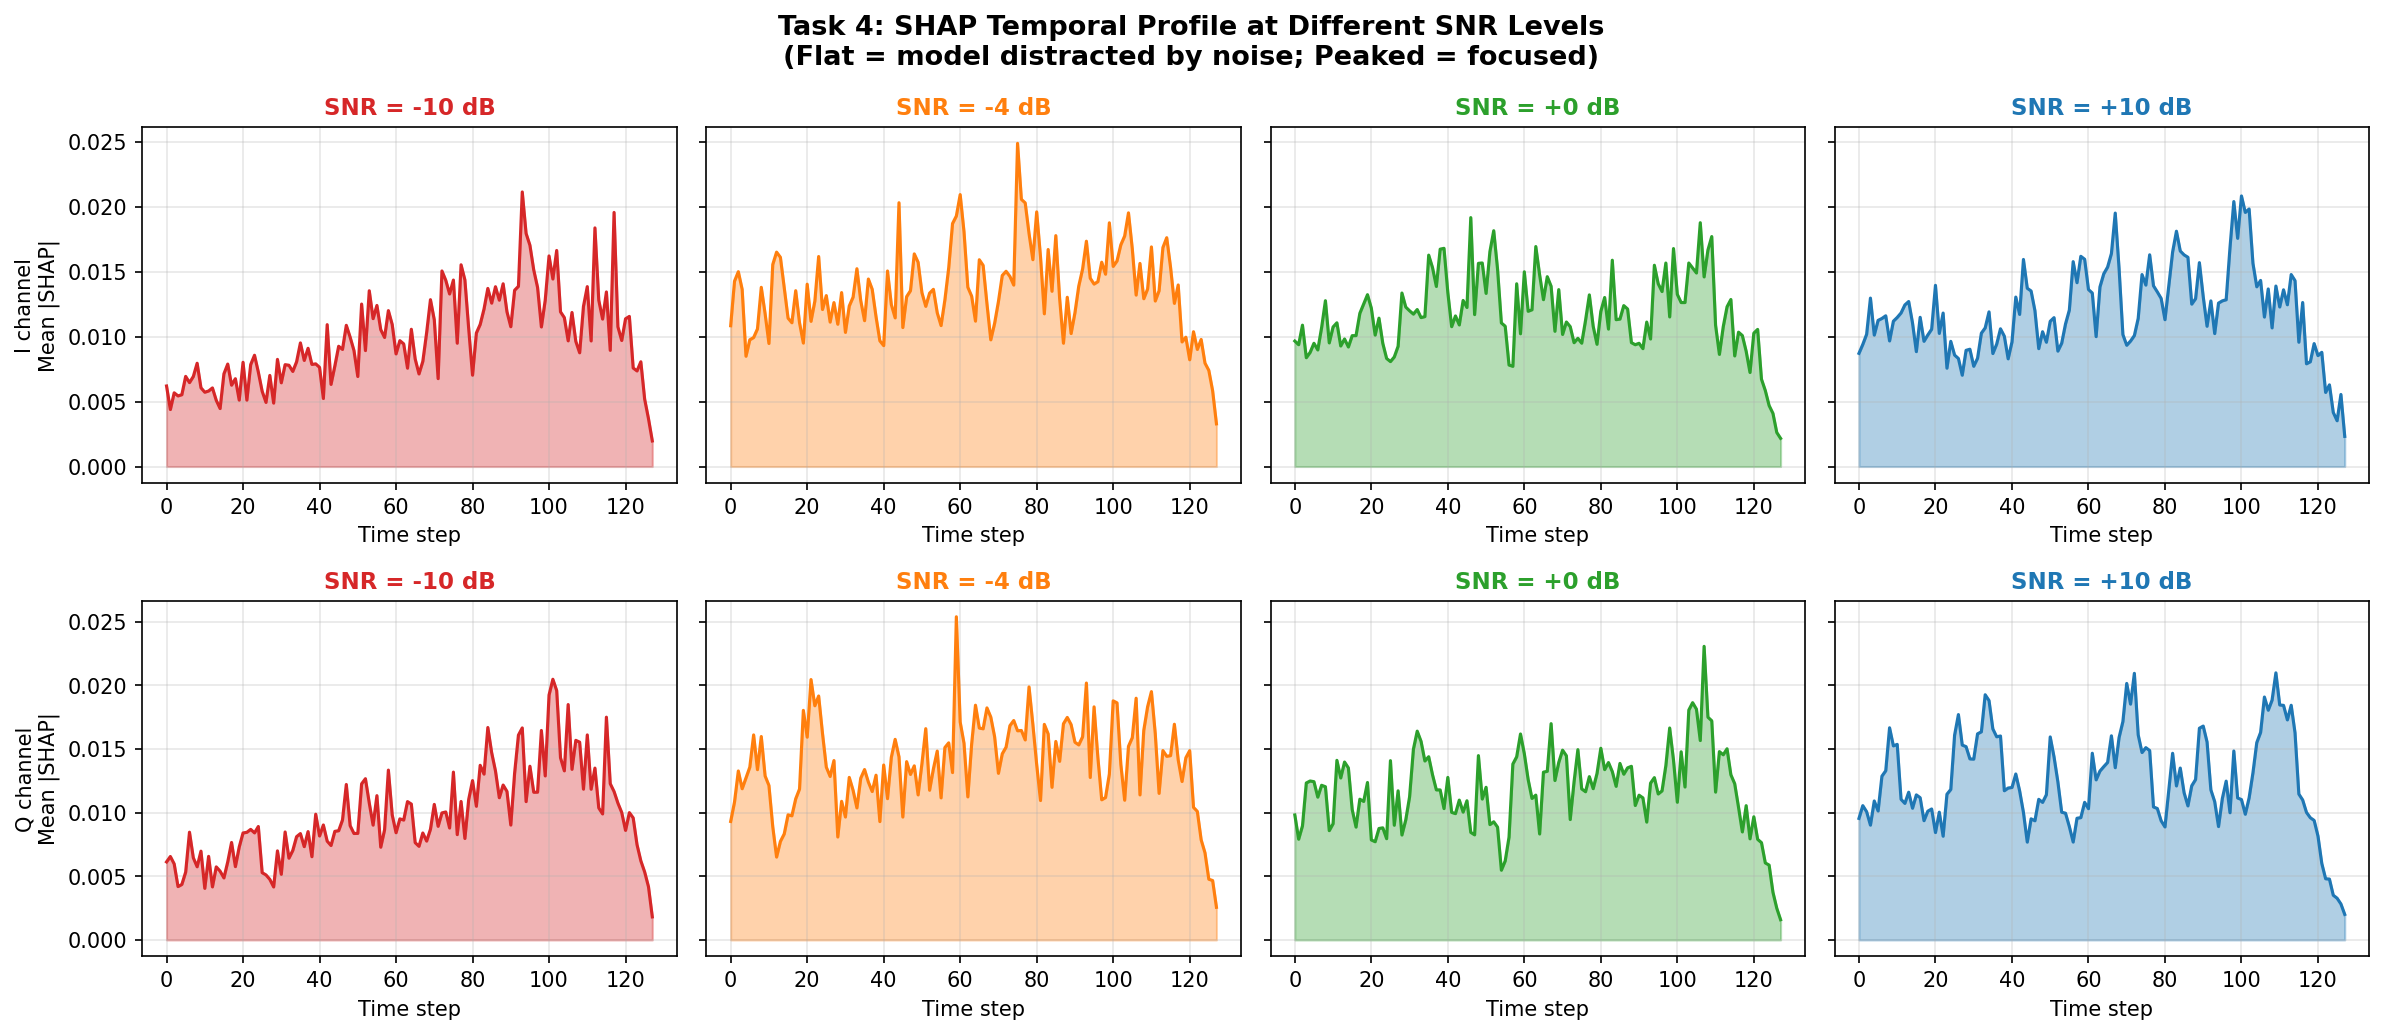


── Task 4 — Dispersion vs SNR ──


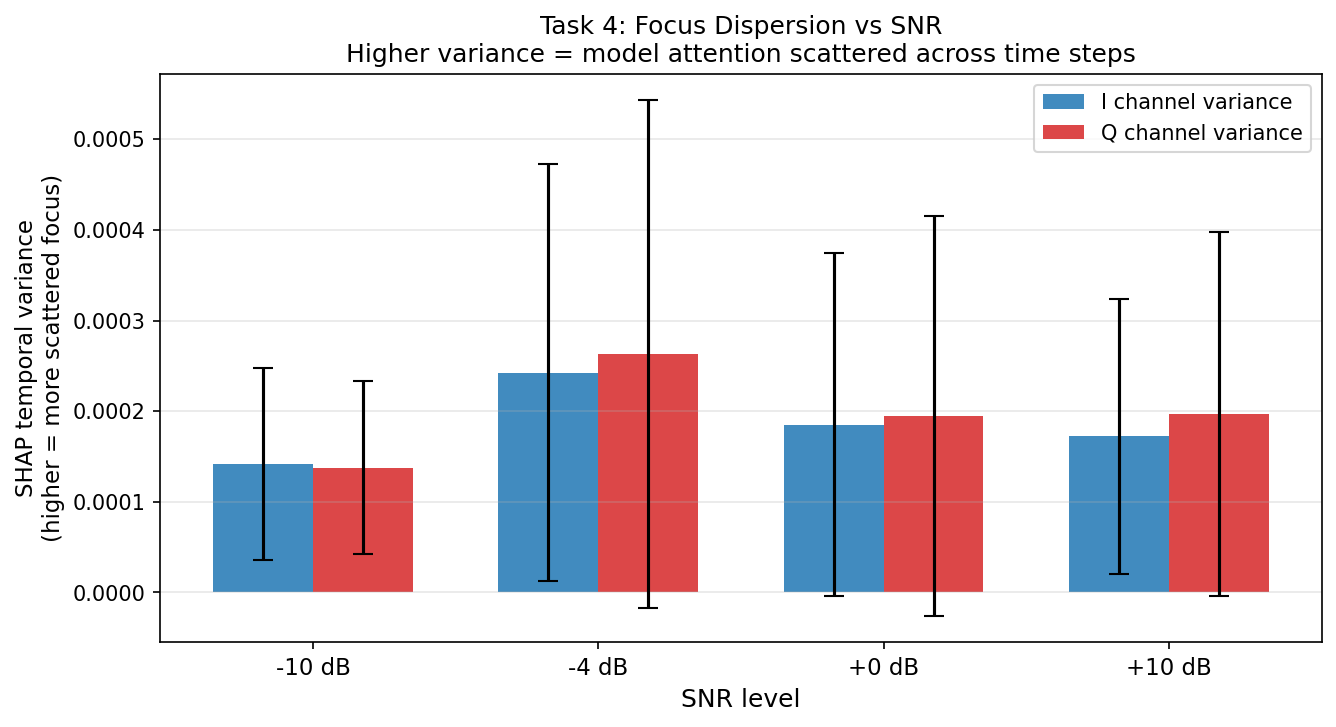


── Task 5 — Confusion Analysis ──


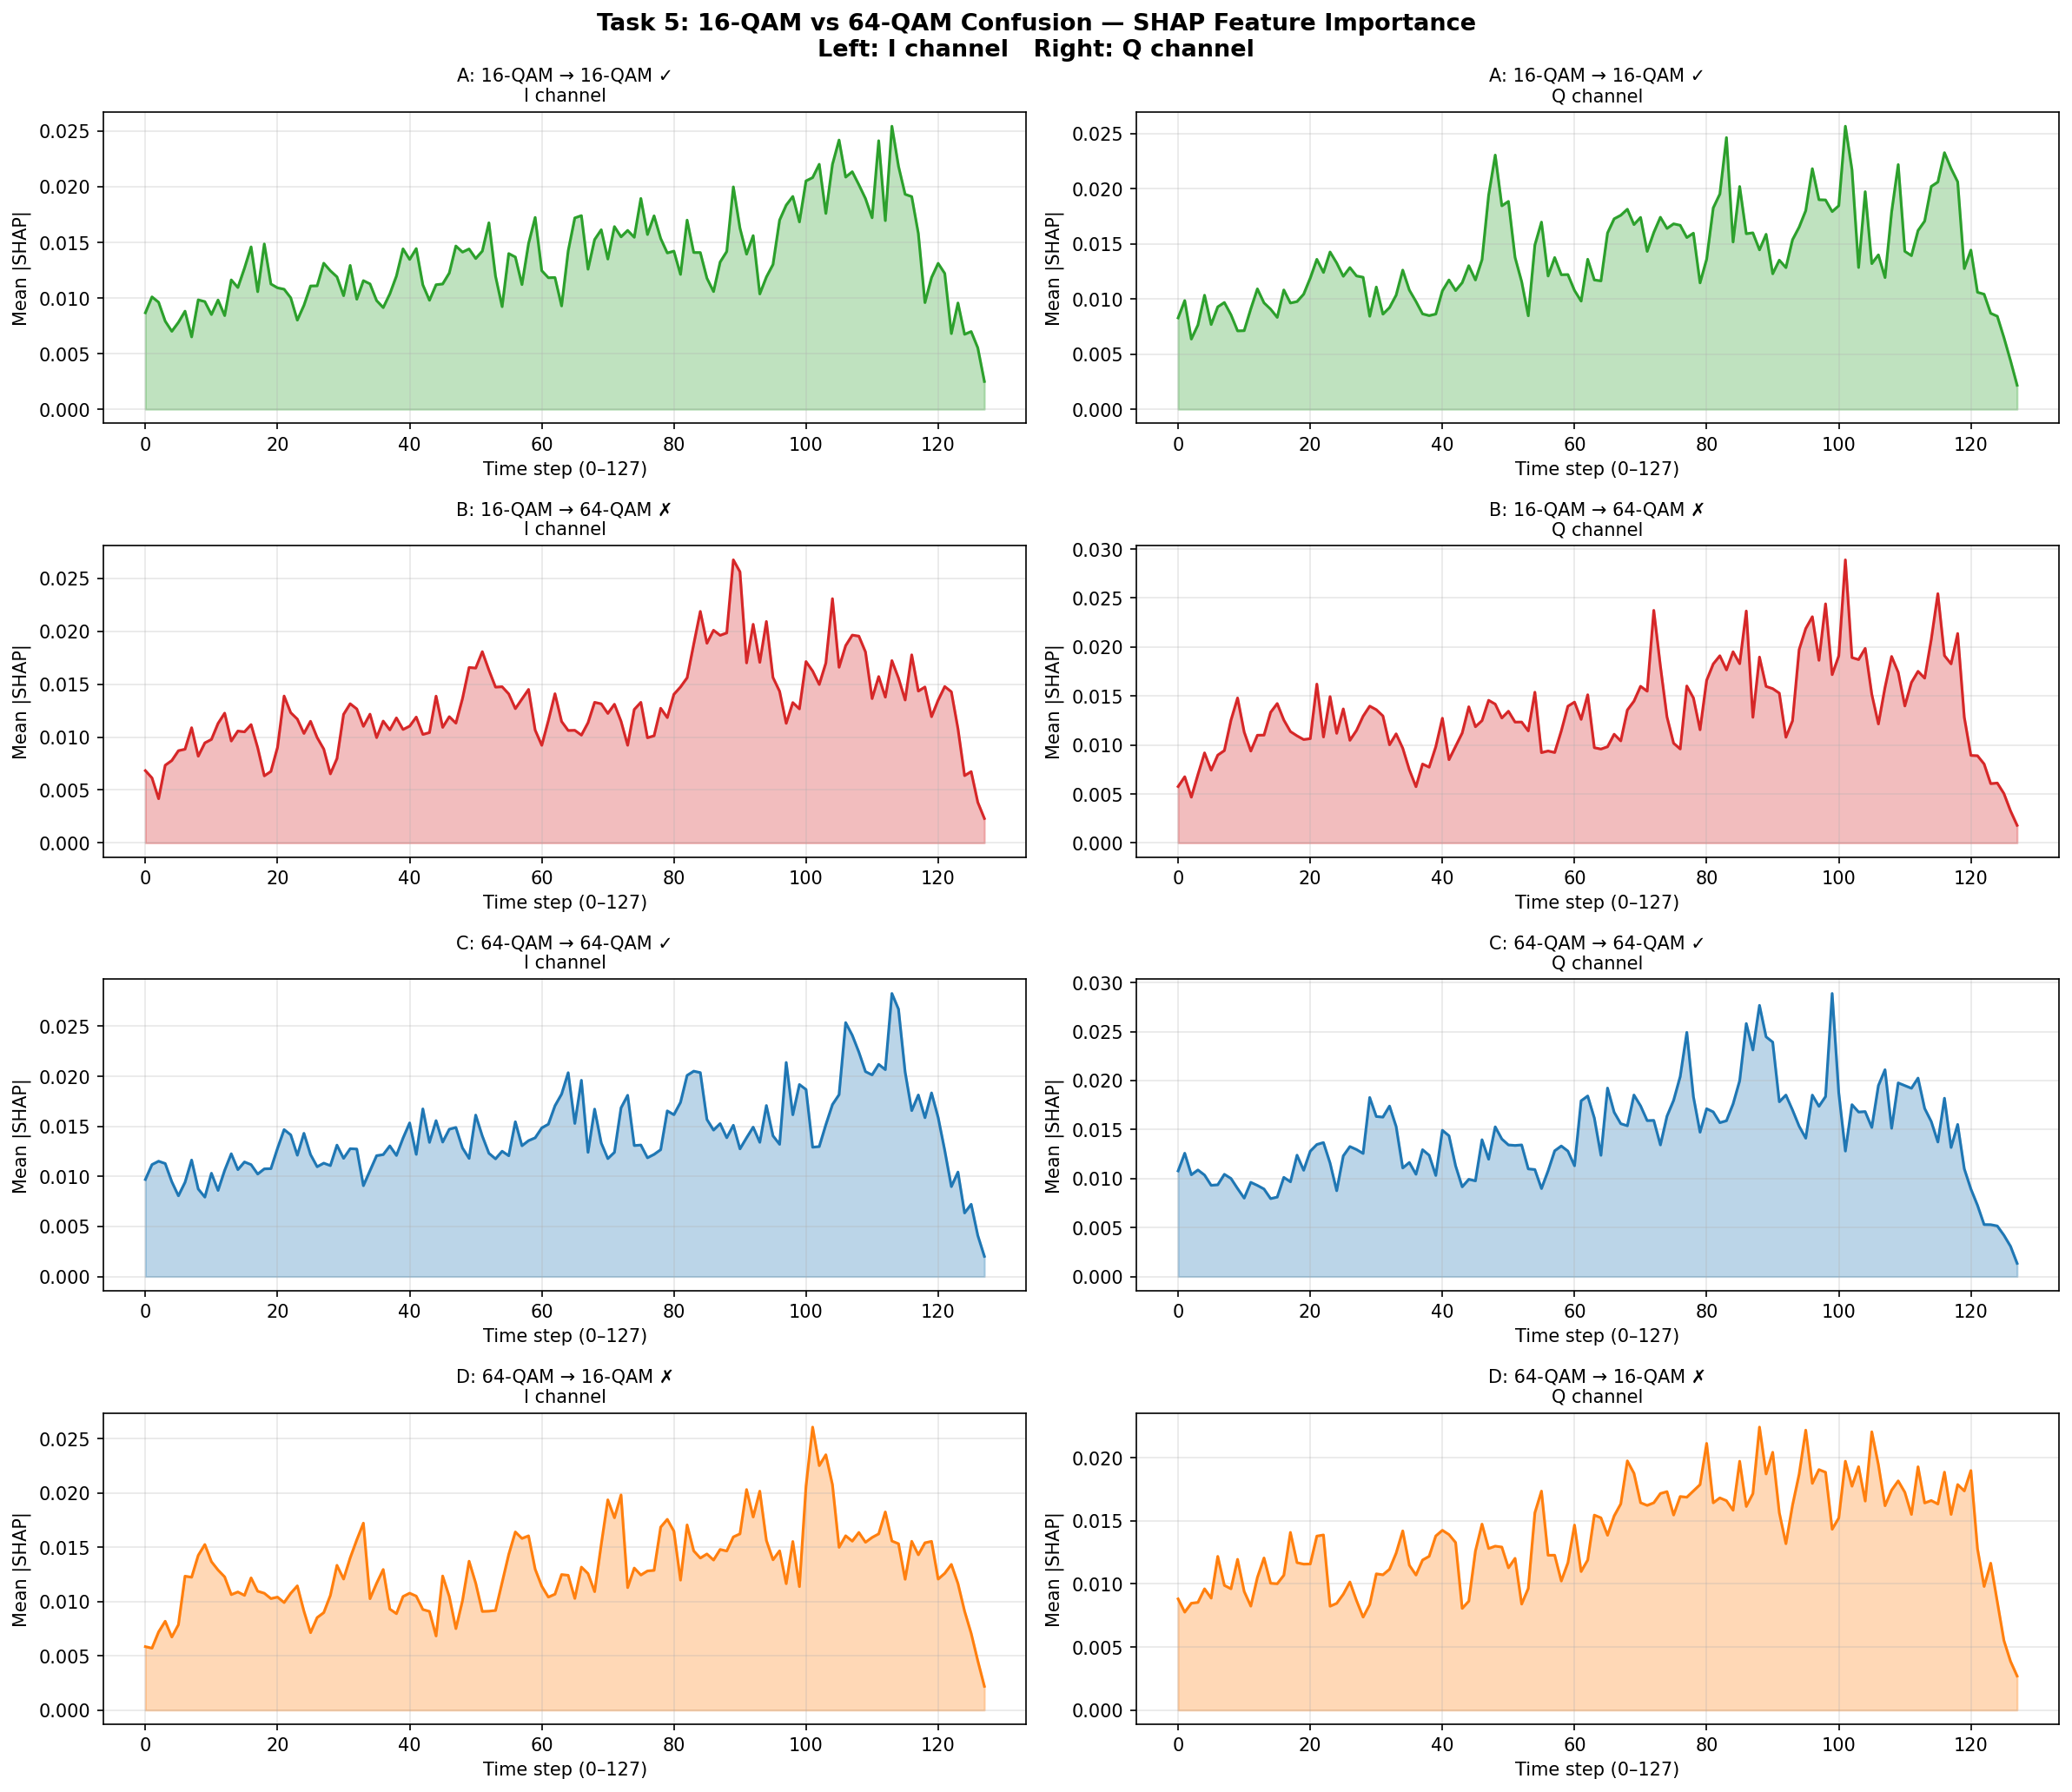


── Task 5 — SI/SQ Comparison ──


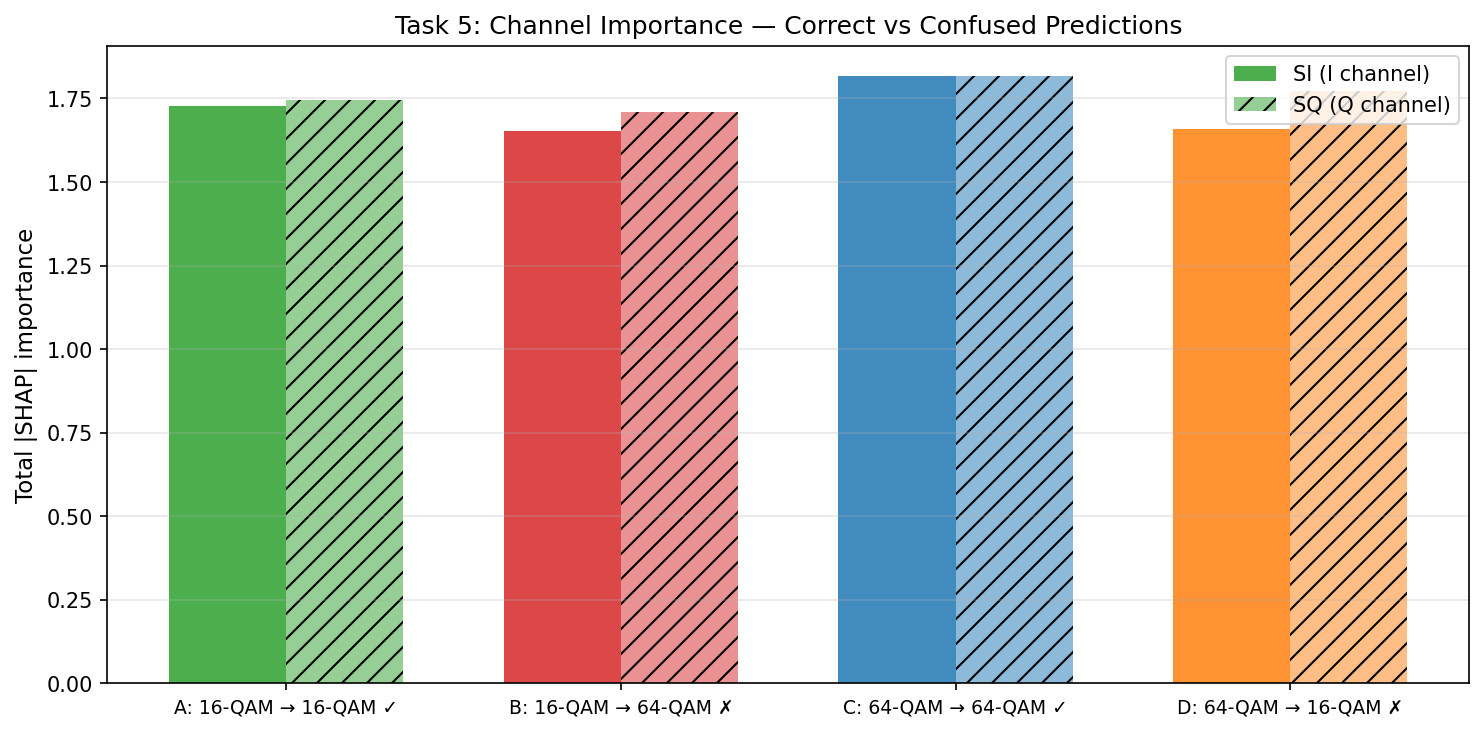

In [35]:

# Display all saved SHAP plots inline
from IPython.display import Image, display

all_plots = [
    ('Task 2 — Temporal Distribution',  f'{SHAP_DIR}/task2_temporal_distribution.png'),
    ('Task 3 — I vs Q Balance',         f'{SHAP_DIR}/task3_IQ_balance.png'),
    ('Task 4 — SNR Temporal Profiles',  f'{SHAP_DIR}/task4_snr_temporal_profiles.png'),
    ('Task 4 — Dispersion vs SNR',      f'{SHAP_DIR}/task4_dispersion_vs_snr.png'),
    ('Task 5 — Confusion Analysis',     f'{SHAP_DIR}/task5_confusion_analysis.png'),
    ('Task 5 — SI/SQ Comparison',       f'{SHAP_DIR}/task5_SI_SQ_comparison.png'),
]
for title, path in all_plots:
    if os.path.exists(path):
        print(f"\n── {title} ──")
        display(Image(path))
    else:
        print(f"  ⚠️  Not found: {path}")

In [36]:
# Download everything including SHAP outputs


import shutil, glob

OUT = '/kaggle/working/full_results'
os.makedirs(OUT, exist_ok=True)

for f in glob.glob('experiments/**/*', recursive=True):
    if os.path.isfile(f):
        dest = os.path.join(OUT, f)
        os.makedirs(os.path.dirname(dest), exist_ok=True)
        shutil.copy2(f, dest)

shutil.make_archive('/kaggle/working/full_results', 'zip', OUT)
size = os.path.getsize('/kaggle/working/full_results.zip') / 1e6
print(f"Saved: /kaggle/working/full_results.zip  ({size:.2f} MB)")

# List SHAP outputs specifically
print(f"\nSHAP outputs:")
for f in sorted(glob.glob(f'{SHAP_DIR}/*')):
    print(f"  {os.path.basename(f)}  ({os.path.getsize(f)/1e3:.1f} KB)")

Saved: /kaggle/working/full_results.zip  (8.63 MB)

SHAP outputs:
  task2_data.pkl  (410.2 KB)
  task2_temporal_distribution.png  (1111.1 KB)
  task3_IQ_balance.png  (75.5 KB)
  task3_data.pkl  (5.8 KB)
  task4_data.pkl  (10.9 KB)
  task4_dispersion_vs_snr.png  (65.9 KB)
  task4_snr_temporal_profiles.png  (313.9 KB)
  task5_SI_SQ_comparison.png  (71.3 KB)
  task5_confusion_analysis.png  (501.6 KB)
  task5_data.pkl  (9.0 KB)
